# PHASE 5 — Diagnosis-Driven Mitigation (Variant 1: full-severity-range augmentation)

## Cell 1 — Install dependencies

In [2]:
import subprocess, sys
def _pip_install(pkg):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)
for pkg in ["ultralytics", "albumentations", "opencv-python-headless", "openpyxl"]:
    _pip_install(pkg)
import torch
print("Torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
DEVICE = 0 if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 693.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 5.2 MB/s eta 0:00:00
Torch: 2.10.0+cu128 | CUDA available: True
Using device: 0


## Cell 2 — Imports

In [3]:
import os, glob, json, random, shutil, time
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import yaml as pyyaml
from ultralytics import YOLO

print("Imports OK")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Imports OK


## Cell 3 — Configuration (VARIANT 1: augmentation ranges widened to cover the FULL
Phase 3 severity spectrum, not just the high-severity half)

In [5]:
SEED = 123
IMG_SIZE = 640
EVAL_CONF = 0.001          # for correct mAP curve integration (matches Phase 3 reasoning)
CONF_THRESHOLD = 0.25      # for VISUALIZATION only (sample prediction images) -- never use this for mAP
IOU_THRESHOLD = 0.70       # matches Phase 3 (Ultralytics default NMS IoU, no override there)

TRAIN_EPOCHS = 150
TRAIN_PATIENCE = 30
TRAIN_BATCH = 12
TRAIN_OPTIMIZER = "SGD"    # confirmed from the actual training log (auto resolved to SGD)
TRAIN_LR0 = 0.01
TRAIN_LRF = 0.01
TRAIN_MOMENTUM = 0.937
TRAIN_WEIGHT_DECAY = 0.0005
TRAIN_WARMUP_EPOCHS = 3.0
TRAIN_WARMUP_MOMENTUM = 0.8
TRAIN_WARMUP_BIAS_LR = 0.1
TRAIN_SEED = SEED  # was hardcoded 42, now linked so changing SEED actually changes the Ultralytics-internal training seed
TRAIN_DETERMINISTIC = True
TRAIN_CLOSE_MOSAIC = 20
TRAIN_COS_LR = False

BASELINE_AUG = dict(
    hsv_h=0.02, hsv_s=0.7, hsv_v=0.5,
    degrees=10.0, translate=0.1, scale=0.5, shear=0.0, perspective=0.0,
    flipud=0.0, fliplr=0.5, bgr=0.0,
    mosaic=1.0, mixup=0.0, cutmix=0.0, copy_paste=0.0, copy_paste_mode="flip",
    auto_augment="randaugment", erasing=0.4,
)

# ---------------------------------------------------------------------------
# VARIANT 1 FIX: Phase 3 severity levels were
#   Low-Light darkening factor : sev1=0.80, sev2=0.60, sev3=0.40, sev4=0.20
#   Gaussian Noise std          : sev1=0.03, sev2=0.06, sev3=0.10, sev4=0.15
# The original run only covered (0.15, 0.45) for low-light and (0.05, 0.15) for
# noise -- missing the LIGHT end of both spectra (sev1-2 low-light, sev1 noise).
# This is the most likely reason Low-Light showed flat/negative results at
# severities 1-3 while only severity 4 (which WAS covered) improved.
# Variant 1 widens both ranges to cover the full spectrum end-to-end.
# ---------------------------------------------------------------------------
TARGETED_LOWLIGHT_PROB = 0.35
TARGETED_LOWLIGHT_FACTOR_RANGE = (0.15, 0.85)   # was (0.15, 0.45)

TARGETED_NOISE_PROB = 0.35
TARGETED_NOISE_STD_RANGE = (0.02, 0.16)         # was (0.05, 0.15)

random.seed(SEED)
np.random.seed(SEED)

OUTPUT_ROOT = f"/kaggle/working/phase5_mitigation_seed{SEED}"
TRAINING_DIR = os.path.join(OUTPUT_ROOT, "training")
MODELS_DIR = os.path.join(OUTPUT_ROOT, "models")
RESULTS_DIR = os.path.join(OUTPUT_ROOT, "results")
PLOTS_DIR = os.path.join(OUTPUT_ROOT, "plots")
CONFIGS_DIR = os.path.join(OUTPUT_ROOT, "configs")
LOGS_DIR = os.path.join(OUTPUT_ROOT, "logs")
for d in [OUTPUT_ROOT, TRAINING_DIR, MODELS_DIR, RESULTS_DIR, PLOTS_DIR, CONFIGS_DIR, LOGS_DIR]:
    os.makedirs(d, exist_ok=True)

DPI = 300
print("Phase 5 (Variant 1) configuration loaded.")
print("Low-light factor range:", TARGETED_LOWLIGHT_FACTOR_RANGE)
print("Noise std range       :", TARGETED_NOISE_STD_RANGE)

BEFORE_LABEL = "Baseline"
AFTER_LABEL = "Targeted Mitigation"


Phase 5 (Variant 1) configuration loaded.
Low-light factor range: (0.15, 0.85)
Noise std range       : (0.02, 0.16)


## Cell 4 — Locate Phase 3 output (before-model, clean+degraded test sets)

Dynamic search (works whether the Phase 3 zip is a Kaggle Input dataset or in this
session's own /kaggle/working).

In [6]:
def find_phase3_root():
    candidates = []
    for root in ("/kaggle/input", "/kaggle/working"):
        for config_path in glob.glob(os.path.join(root, "**", "phase3_config.json"), recursive=True):
            d = os.path.dirname(config_path)
            if os.path.isdir(os.path.join(d, "degraded_datasets")):
                candidates.append(d)
    return sorted(set(candidates))

phase3_candidates = find_phase3_root()
print("Phase 3 root candidates:")
for c in phase3_candidates:
    print(" -", c)
if not phase3_candidates:
    raise FileNotFoundError("No Phase 3 output found. Add the Phase 3 output zip as a Kaggle Input dataset.")
PHASE3_ROOT = phase3_candidates[0]

with open(os.path.join(PHASE3_ROOT, "phase3_config.json")) as f:
    phase3_config = json.load(f)

BEFORE_MODEL_PATH = os.path.join(PHASE3_ROOT, "model", "best.pt")
if not os.path.exists(BEFORE_MODEL_PATH):
    cands = glob.glob("/kaggle/input/**/best.pt", recursive=True)
    if not cands:
        raise FileNotFoundError("No baseline best.pt found (bundled copy missing and no other candidate).")
    BEFORE_MODEL_PATH = cands[0]
print("\nBEFORE_MODEL_PATH (Phase 1/2 baseline):", BEFORE_MODEL_PATH)

CLEAN_TEST_IMAGES_DIR = os.path.join(PHASE3_ROOT, "clean_test_set", "images")
CLEAN_TEST_LABELS_DIR = os.path.join(PHASE3_ROOT, "clean_test_set", "labels")
if not os.path.isdir(CLEAN_TEST_IMAGES_DIR):
    raise FileNotFoundError("Bundled clean_test_set not found in the Phase 3 output.")
print("CLEAN_TEST_IMAGES_DIR:", CLEAN_TEST_IMAGES_DIR)

DEGRADED_DIR = os.path.join(PHASE3_ROOT, "degraded_datasets")
DEGRADATION_DIRS = {
    "Gaussian Noise": os.path.join(DEGRADED_DIR, "gaussian_noise"),
    "Motion Blur": os.path.join(DEGRADED_DIR, "motion_blur"),
    "Low Light": os.path.join(DEGRADED_DIR, "low_light"),
}
for name, d in DEGRADATION_DIRS.items():
    print(f"{name} exists: {os.path.isdir(d)} -> {d}")

SEVERITY_PARAMS = phase3_config.get("severity_params", {})
SEVERITIES = sorted({int(s) for grp in SEVERITY_PARAMS.values() for s in grp.keys()}) or [1, 2, 3, 4]
print("\nSeverities to evaluate:", SEVERITIES)

CLASS_NAMES = phase3_config.get("class_names", ["Fire", "Smoke"])
NUM_CLASSES = len(CLASS_NAMES)
print("CLASS_NAMES:", CLASS_NAMES)

Phase 3 root candidates:
 - /kaggle/input/datasets/mdshaparan/output-result-03

BEFORE_MODEL_PATH (Phase 1/2 baseline): /kaggle/input/datasets/mdshaparan/output-result-03/model/best.pt
CLEAN_TEST_IMAGES_DIR: /kaggle/input/datasets/mdshaparan/output-result-03/clean_test_set/images
Gaussian Noise exists: True -> /kaggle/input/datasets/mdshaparan/output-result-03/degraded_datasets/gaussian_noise
Motion Blur exists: True -> /kaggle/input/datasets/mdshaparan/output-result-03/degraded_datasets/motion_blur
Low Light exists: True -> /kaggle/input/datasets/mdshaparan/output-result-03/degraded_datasets/low_light

Severities to evaluate: [1, 2, 3, 4]
CLASS_NAMES: ['Fire', 'Smoke']


## Cell 5 — Locate / download the FULL training dataset (train+val)

In [7]:
train_data_candidates = glob.glob("/kaggle/input/**/train/images", recursive=True) + \
                         glob.glob("/kaggle/working/**/train/images", recursive=True)
print("Existing train/images candidates found:", train_data_candidates)

if train_data_candidates:
    TRAIN_DATASET_ROOT = os.path.dirname(os.path.dirname(train_data_candidates[0]))
    print("Using existing dataset at:", TRAIN_DATASET_ROOT)
else:
    print("No training dataset found in this session -- downloading from Roboflow (deterministic version).")
    _pip_install("roboflow")
    from roboflow import Roboflow

    ROBOFLOW_API_KEY = "qNZt21Yr4LTdIaH6fUXC"  # regenerate this key, the old one was exposed
    WORKSPACE = "md-s-workspace"
    PROJECT = "fire_smoke_detection-tmqte"
    VERSION = 4

    rf = Roboflow(api_key=ROBOFLOW_API_KEY)
    project = rf.workspace(WORKSPACE).project(PROJECT)
    dataset = project.version(VERSION).download("yolov11")
    TRAIN_DATASET_ROOT = dataset.location
    print("Downloaded to:", TRAIN_DATASET_ROOT)

DATA_YAML_PATH = os.path.join(TRAIN_DATASET_ROOT, "data.yaml")
print("\nUsing data.yaml:", DATA_YAML_PATH, "| exists:", os.path.exists(DATA_YAML_PATH))

Existing train/images candidates found: ['/kaggle/working/fire_smoke_detection-4/train/images']
Using existing dataset at: /kaggle/working/fire_smoke_detection-4

Using data.yaml: /kaggle/working/fire_smoke_detection-4/data.yaml | exists: True


## Cell 6 — Document the diagnosis -> augmentation mapping

In [8]:
diagnosis_rationale = {
    "targeted_failure_modes": {
        "Low-Light FN": {
            "evidence": "LowLight_FN_011: GT_Box_Activation_Ratio=0.755, genuine object-relevant "
                        "Grad-CAM activation at the fire location under severe low light, but below "
                        "the detection confidence threshold. (LowLight_FN_009/012 showed near-zero "
                        "ratios -- evidence is partial/mixed, not uniform across all cases.)",
            "augmentation_added": f"Custom low-light darkening transform, p={TARGETED_LOWLIGHT_PROB}, "
                                   f"factor range={TARGETED_LOWLIGHT_FACTOR_RANGE} (V-channel scaling). "
                                   f"VARIANT 1: range widened to cover the full Phase 3 severity spectrum "
                                   f"(0.80 to 0.20), not just the high-severity half.",
        },
        "Gaussian Noise FP": {
            "evidence": "Noise_Failure_018: Grad-CAM signal itself was diffuse and low-contrast across "
                        "the whole image, consistent with broad feature-response degradation.",
            "augmentation_added": f"Custom Gaussian noise transform, p={TARGETED_NOISE_PROB}, "
                                   f"std range={TARGETED_NOISE_STD_RANGE}. VARIANT 1: range widened to "
                                   f"also cover severity 1 (std=0.03).",
        },
    },
    "explicitly_excluded_failure_modes": {
        "Glare -> Fire FP": "Glare_Fire_FP_001 and _003 both showed the strongest Grad-CAM activation "
                            "on genuine fire elsewhere in the image, NOT on the glare-like predicted "
                            "box. No CAM evidence supported a glare-driven confusion.",
        "Fog/Cloud -> Smoke FP": "Fog_Smoke_FP_005 showed the predicted box was on genuine smoke (not "
                                 "fog), with the dominant activation at an unrelated image edge.",
        "Motion Blur": "MotionBlur_Failure_013/014/015/016 all showed the recurring edge-artifact "
                       "pattern rather than a blur-specific signal; evidence was too weak to justify "
                       "targeting, consistent with the same evidence-constrained standard applied to "
                       "glare and fog.",
    },
    "known_limitation": "This Phase 5 run does NOT include a blanket-augmentation control condition. "
                         "Improvement here cannot be definitively attributed to TARGETED augmentation "
                         "specifically versus augmentation in general.",
}

rationale_path = os.path.join(CONFIGS_DIR, "diagnosis_to_augmentation_rationale.json")
with open(rationale_path, "w") as f:
    json.dump(diagnosis_rationale, f, indent=2)
print("Diagnosis-to-augmentation rationale saved to:", rationale_path)

Diagnosis-to-augmentation rationale saved to: /kaggle/working/phase5_mitigation_seed123/configs/diagnosis_to_augmentation_rationale.json


## Cell 7 — Diagnostic: inspect Ultralytics' YOLODataset.build_transforms() BEFORE patching

In [9]:
from ultralytics.data.dataset import YOLODataset
from ultralytics.utils import IterableSimpleNamespace
import ultralytics.cfg as ucfg

_default_hyp = IterableSimpleNamespace(**{**ucfg.get_cfg(ucfg.DEFAULT_CFG_DICT).__dict__, **BASELINE_AUG})

_probe_ds = YOLODataset(
    img_path=os.path.join(TRAIN_DATASET_ROOT, "train", "images"),
    data={"names": {i: n for i, n in enumerate(CLASS_NAMES)}, "channels": 3},
    task="detect",
    imgsz=IMG_SIZE,
    augment=True,
    hyp=_default_hyp,
)
_probe_transforms = _probe_ds.build_transforms(hyp=_default_hyp)
print("Transform pipeline (in order):")
for i, t in enumerate(_probe_transforms.transforms):
    print(f"  [{i}] {t.__class__.__name__}")
print("\nIf the LAST entry above is 'Format', Cell 8's patch (inserting before the last entry) is correct.")

Fast image access ✅ (ping: 0.0±0.0 ms, read: 1327.8±353.3 MB/s, size: 43.0 KB)
Scanning /kaggle/working/fire_smoke_detection-4/train/labels.cache... 8089 images, 1419 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 8089/8089 1.4Git/s 0.0s
/kaggle/working/fire_smoke_detection-4/train/images/middle_-2348-_jpg.rf.a4cd078442e8fac068e55eb1c2557728.jpg: ignoring corrupt image/label: labels mix segment and detection rows
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
Transform pipeline (in order):
  [0] Compose
  [1] MixUp
  [2] CutMix
  [3] Albumentations
  [4] RandomHSV
  [5] RandomFlip
  [6] RandomFlip
  [7] Format

If th

## Cell 8 — Patch build_transforms to ADDITIVELY insert the two targeted transforms

Idempotent version: safe to re-run this cell any number of times without causing
infinite recursion, even across kernel states.

In [11]:
class TargetedLowLightNoise:
    """Custom Ultralytics-style transform: operates on labels['img'] (BGR uint8 HWC numpy array)."""
    def __init__(self, p_lowlight, lowlight_range, p_noise, noise_std_range):
        self.p_lowlight = p_lowlight
        self.lowlight_range = lowlight_range
        self.p_noise = p_noise
        self.noise_std_range = noise_std_range

    def _apply_lowlight(self, img):
        factor = random.uniform(*self.lowlight_range)
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)
        hsv[:, :, 2] = np.clip(hsv[:, :, 2] * factor, 0, 255)
        return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

    def _apply_noise(self, img):
        std = random.uniform(*self.noise_std_range)
        img_f = img.astype(np.float32) / 255.0
        noise = np.random.normal(0.0, std, img_f.shape).astype(np.float32)
        noisy = np.clip(img_f + noise, 0.0, 1.0)
        return (noisy * 255.0).astype(np.uint8)

    def __call__(self, labels):
        img = labels["img"]
        if random.random() < self.p_lowlight:
            img = self._apply_lowlight(img)
        if random.random() < self.p_noise:
            img = self._apply_noise(img)
        labels["img"] = img
        return labels


if not hasattr(YOLODataset, "_phase5_true_original_build_transforms"):
    current = YOLODataset.__dict__.get("build_transforms")
    while current is not None and getattr(current, "_is_phase5_patch", False):
        current = current._wrapped_original
    YOLODataset._phase5_true_original_build_transforms = current
    print("Captured the TRUE original build_transforms (first time in this session).")
else:
    print("TRUE original build_transforms already captured earlier -- reusing it.")

_true_original = YOLODataset._phase5_true_original_build_transforms

def _patched_build_transforms(self, hyp=None):
    transforms = _true_original(self, hyp)
    if getattr(self, "augment", False):
        targeted = TargetedLowLightNoise(
            p_lowlight=TARGETED_LOWLIGHT_PROB,
            lowlight_range=TARGETED_LOWLIGHT_FACTOR_RANGE,
            p_noise=TARGETED_NOISE_PROB,
            noise_std_range=TARGETED_NOISE_STD_RANGE,
        )
        insert_at = len(transforms.transforms) - 1 if len(transforms.transforms) > 0 else 0
        transforms.transforms.insert(insert_at, targeted)
        print(f"[Phase 5] Inserted TargetedLowLightNoise at position {insert_at} "
              f"(pipeline now has {len(transforms.transforms)} transforms).")
    return transforms

_patched_build_transforms._is_phase5_patch = True
_patched_build_transforms._wrapped_original = _true_original
YOLODataset.build_transforms = _patched_build_transforms
print("Patched YOLODataset.build_transforms (idempotent version -- safe to re-run this cell).")

TRUE original build_transforms already captured earlier -- reusing it.
Patched YOLODataset.build_transforms (idempotent version -- safe to re-run this cell).


## Cell 9 — Evaluation utilities (single definition, used for BOTH Before and After)

Includes per-class AP50 from the start -- no need to re-evaluate later.

In [12]:
def make_data_yaml(images_dir, yaml_path, names):
    split_root = os.path.dirname(images_dir)
    data = {"path": split_root, "train": "images", "val": "images",
            "names": {i: n for i, n in enumerate(names)}}
    with open(yaml_path, "w") as f:
        pyyaml.dump(data, f)
    return yaml_path

def evaluate_model(model, images_dir, name, conf=EVAL_CONF, iou=IOU_THRESHOLD, imgsz=IMG_SIZE):
    yaml_path = os.path.join(LOGS_DIR, f"data_{name}.yaml")
    make_data_yaml(images_dir, yaml_path, CLASS_NAMES)
    metrics = model.val(data=yaml_path, imgsz=imgsz, conf=conf, iou=iou, split="val",
                         device=DEVICE, verbose=False, plots=False, save_json=False)
    per_class_ap50 = {}
    try:
        ap50_per_class = metrics.box.ap50
        for i, cname in enumerate(CLASS_NAMES):
            per_class_ap50[f"{cname}_AP50"] = float(ap50_per_class[i]) if i < len(ap50_per_class) else None
    except Exception as e:
        print(f"  WARNING: could not extract per-class AP50 for {name}: {e}")
        for cname in CLASS_NAMES:
            per_class_ap50[f"{cname}_AP50"] = None
    return {
        "Precision": float(metrics.box.mp),
        "Recall": float(metrics.box.mr),
        "mAP50": float(metrics.box.map50),
        "mAP50_95": float(metrics.box.map),
        **per_class_ap50,
    }

def evaluate_all_conditions(model, tag):
    rows = []
    print(f"\n--- Evaluating {tag} model ---")
    print("Clean test set...")
    m = evaluate_model(model, CLEAN_TEST_IMAGES_DIR, f"{tag}_clean")
    rows.append({"Model": tag, "Degradation": "Clean", "Severity": 0, **m})

    for deg_name, deg_dir in DEGRADATION_DIRS.items():
        deg_key = deg_name.lower().replace(" ", "_")
        for sev in SEVERITIES:
            sev_dir = os.path.join(deg_dir, f"severity_{sev}", "images")
            if not os.path.isdir(sev_dir):
                print(f"  Skipping {deg_name} severity {sev}: not found.")
                continue
            print(f"{deg_name} severity {sev}...")
            m = evaluate_model(model, sev_dir, f"{tag}_{deg_key}_sev{sev}")
            rows.append({"Model": tag, "Degradation": deg_name, "Severity": sev, **m})
    return pd.DataFrame(rows)

print("Evaluation utilities ready (with per-class AP50).")

Evaluation utilities ready (with per-class AP50).


## Cell 10 — BEFORE evaluation: Phase 1/2 baseline model

In [13]:
before_model = YOLO(BEFORE_MODEL_PATH)
before_df = evaluate_all_conditions(before_model, "Before")
before_csv = os.path.join(RESULTS_DIR, "before_results.csv")
before_df.to_csv(before_csv, index=False)
print("\nSaved:", before_csv)
before_df


--- Evaluating Before model ---
Clean test set...
Ultralytics 8.4.137 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11s summary (fused): 101 layers, 9,413,574 parameters, 0 gradients, 21.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 12.9±4.2 MB/s, size: 38.2 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /kaggle/input/datasets/mdshaparan/output-result-03/clean_test_set/labels... 1715 images, 287 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1715/1715 417.0it/s 4.1s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/mdshaparan/output-result-03/clean_test_set is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 108/108 5.6it/s 19.2s0.2s
                   all       1715       2790      0.869      0.763      0.828      0.625
Speed: 0.7ms 

,Model,Degradation,Severity,Precision,Recall,mAP50,mAP50_95,Fire_AP50,Smoke_AP50
0,Before,Clean,0,0.869361,0.762934,0.828040,0.625484,0.872152,0.783928
1,Before,Gaussian Noise,1,0.855555,0.716088,0.783998,0.590691,0.851942,0.716054
2,Before,Gaussian Noise,2,0.775929,0.576955,0.636428,0.484954,0.761404,0.511453
3,Before,Gaussian Noise,3,0.783000,0.465214,0.516404,0.402309,0.644998,0.387811
4,Before,Gaussian Noise,4,0.664069,0.356103,0.370867,0.276117,0.513996,0.227737
5,Before,Motion Blur,1,0.877249,0.756887,0.827109,0.624187,0.873843,0.780376
6,Before,Motion Blur,2,0.871974,0.731861,0.809976,0.603373,0.851552,0.768400
7,Before,Motion Blur,3,0.870828,0.690419,0.775272,0.566320,0.818269,0.732274
8,Before,Motion Blur,4,0.817626,0.657045,0.724563,0.514225,0.757586,0.691539
9,Before,Low Light,1,0.875656,0.758979,0.826797,0.627010,0.870845,0.782749


## Cell 11 — Fresh YOLO11s training with Variant 1 targeted augmentation

Starts from the COCO-pretrained yolo11s.pt checkpoint, same architecture and
hyperparameter budget as the baseline -- only the augmentation ranges differ
from the original Phase 5 run (widened per Cell 3's Variant 1 fix).

In [11]:
mitigation_model = YOLO("yolo11s.pt")

run_name = f"yolo11s_phase5_mitigation_seed{SEED}"

train_results = mitigation_model.train(
    data=DATA_YAML_PATH,
    epochs=TRAIN_EPOCHS,
    patience=TRAIN_PATIENCE,
    batch=TRAIN_BATCH,
    imgsz=IMG_SIZE,
    device=DEVICE,
    project=TRAINING_DIR,
    name=run_name,
    exist_ok=True,
    optimizer=TRAIN_OPTIMIZER,
    lr0=TRAIN_LR0,
    lrf=TRAIN_LRF,
    momentum=TRAIN_MOMENTUM,
    weight_decay=TRAIN_WEIGHT_DECAY,
    warmup_epochs=TRAIN_WARMUP_EPOCHS,
    warmup_momentum=TRAIN_WARMUP_MOMENTUM,
    warmup_bias_lr=TRAIN_WARMUP_BIAS_LR,
    seed=TRAIN_SEED,
    deterministic=TRAIN_DETERMINISTIC,
    close_mosaic=TRAIN_CLOSE_MOSAIC,
    cos_lr=TRAIN_COS_LR,
    verbose=True,
    plots=True,
    **BASELINE_AUG,
)

AFTER_MODEL_PATH = os.path.join(TRAINING_DIR, run_name, "weights", "best.pt")
print("\nTraining complete.")
print("AFTER_MODEL_PATH:", AFTER_MODEL_PATH, "| exists:", os.path.exists(AFTER_MODEL_PATH))

bundled_after_path = os.path.join(MODELS_DIR, "after_mitigation_best.pt")
shutil.copy2(AFTER_MODEL_PATH, bundled_after_path)
print("Copied best.pt to:", bundled_after_path)

Ultralytics 8.4.137 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=12, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=20, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/fire_smoke_detection-4/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.02, hsv_s=0.7, hsv_v=0.5, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11s_phase

`get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.


      2/150      3.79G      1.387      1.532      1.523         46        640: 100% ━━━━━━━━━━━━ 674/674 4.3it/s 2:360.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 72/72 5.4it/s 13.3s0.2s
                   all       1706       2867       0.71      0.483      0.553      0.348

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/150      3.79G      1.523      1.737       1.63         33        640: 100% ━━━━━━━━━━━━ 674/674 4.3it/s 2:370.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 72/72 5.4it/s 13.4s0.2s
                   all       1706       2867      0.697      0.416      0.462       0.28

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      4/150      3.79G      1.572      1.819      1.682         32        640: 100% ━━━━━━━━━━━━ 674/674 4.3it/s 2:380.2ss
                 Class     Imag

In [23]:
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if f.endswith(".pt"):
            print(os.path.join(root, f))

/kaggle/input/datasets/mdshaparan/output-result-03/model/best.pt
/kaggle/input/datasets/mdshaparan/last-pt/last (2).pt
/kaggle/input/datasets/mdshaparan/best-pt/best (4).pt


In [26]:
AFTER_MODEL_PATH = "/kaggle/input/datasets/mdshaparan/best-pt/best (4).pt"
print("Using:", AFTER_MODEL_PATH)
print("File exists:", os.path.exists(AFTER_MODEL_PATH))

bundled_after_path = os.path.join(MODELS_DIR, "after_mitigation_best.pt")
shutil.copy2(AFTER_MODEL_PATH, bundled_after_path)
print("Copied best.pt to:", bundled_after_path)

Using: /kaggle/input/datasets/mdshaparan/best-pt/best (4).pt
File exists: True
Copied best.pt to: /kaggle/working/phase5_mitigation_seed123/models/after_mitigation_best.pt


## Cell 12 — AFTER evaluation: Variant 1 mitigated model on the SAME Clean + degraded sets

In [27]:
after_model = YOLO(bundled_after_path)
after_df = evaluate_all_conditions(after_model, "After")
after_csv = os.path.join(RESULTS_DIR, "after_results.csv")
after_df.to_csv(after_csv, index=False)
print("\nSaved:", after_csv)
after_df


--- Evaluating After model ---
Clean test set...
Ultralytics 8.4.137 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11s summary (fused): 101 layers, 9,413,574 parameters, 0 gradients, 21.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 49.5±9.9 MB/s, size: 31.5 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /kaggle/input/datasets/mdshaparan/output-result-03/clean_test_set/labels... 1715 images, 287 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1715/1715 1.1Kit/s 1.5s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/mdshaparan/output-result-03/clean_test_set is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 108/108 5.5it/s 19.7s0.2s
                   all       1715       2790      0.879      0.749      0.823      0.618
Speed: 0.7ms pr

,Model,Degradation,Severity,Precision,Recall,mAP50,mAP50_95,Fire_AP50,Smoke_AP50
0,After,Clean,0,0.879403,0.748932,0.823173,0.617947,0.867747,0.778600
1,After,Gaussian Noise,1,0.877305,0.751399,0.823863,0.618240,0.869415,0.778311
2,After,Gaussian Noise,2,0.878098,0.743523,0.822191,0.616793,0.868549,0.775834
3,After,Gaussian Noise,3,0.867966,0.736188,0.819601,0.612525,0.869728,0.769474
4,After,Gaussian Noise,4,0.859327,0.734568,0.810125,0.607751,0.864742,0.755507
5,After,Motion Blur,1,0.881971,0.743592,0.821254,0.616324,0.869296,0.773213
6,After,Motion Blur,2,0.880633,0.732136,0.809586,0.600716,0.860006,0.759166
7,After,Motion Blur,3,0.848304,0.714867,0.785591,0.573897,0.836151,0.735032
8,After,Motion Blur,4,0.853991,0.663319,0.748154,0.533372,0.790798,0.705510
9,After,Low Light,1,0.878640,0.746849,0.825005,0.619368,0.870147,0.779862


## Cell 13 — Confusion matrices (Before + After), normalized only

plots=True is REQUIRED here -- Ultralytics does not populate the confusion_matrix
object when plots=False, even though detection metrics are still correct.


Clean test set...
Ultralytics 8.4.137 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 68.2±17.8 MB/s, size: 33.3 KB)
val: Scanning /kaggle/input/datasets/mdshaparan/output-result-03/clean_test_set/labels... 1715 images, 287 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1715/1715 1.2Kit/s 1.4s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/mdshaparan/output-result-03/clean_test_set is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 108/108 4.8it/s 22.5s0.2s
                   all       1715       2790      0.869      0.763      0.828      0.625
Speed: 0.8ms preprocess, 9.5ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /kaggle/working/phase5_mitigation_seed123/logs/cm_temp_cm_before_clean/run
Ultralytics 8.4.137 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
WARNING ⚠️ val: Slow image

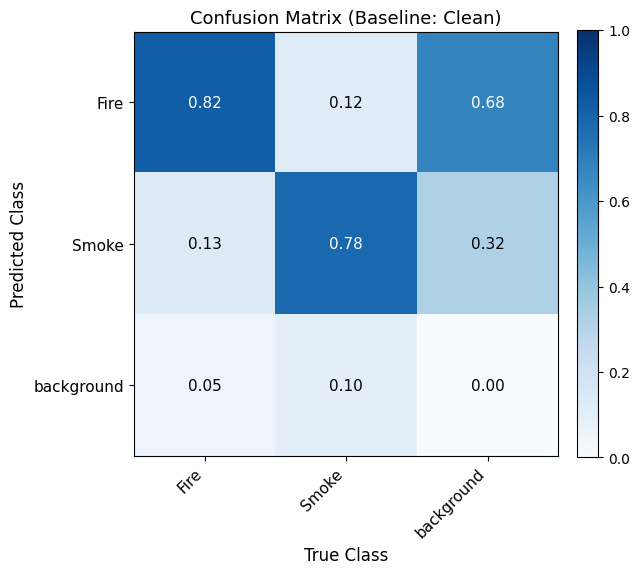

Saved: /kaggle/working/phase5_mitigation_seed123/plots/confusion_matrix_before_clean_normalized.png / .pdf


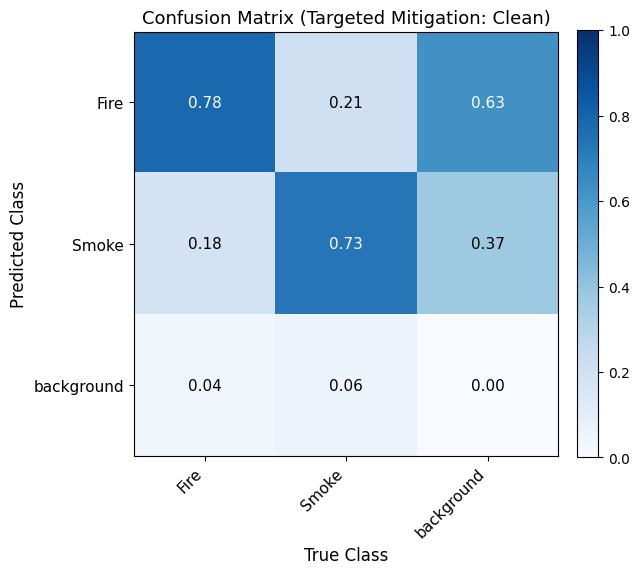

Saved: /kaggle/working/phase5_mitigation_seed123/plots/confusion_matrix_after_clean_normalized.png / .pdf

Low-Light severity 4...
Ultralytics 8.4.137 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 68.0±20.9 MB/s, size: 33.7 KB)
val: Scanning /kaggle/input/datasets/mdshaparan/output-result-03/degraded_datasets/low_light/severity_4/labels... 1715 images, 287 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1715/1715 1.2Kit/s 1.4s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/mdshaparan/output-result-03/degraded_datasets/low_light/severity_4 is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 108/108 5.0it/s 21.8s0.2s
                   all       1715       2790      0.878      0.726      0.791      0.599
Speed: 0.8ms preprocess, 9.2ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /kaggle/working/phase5_mi

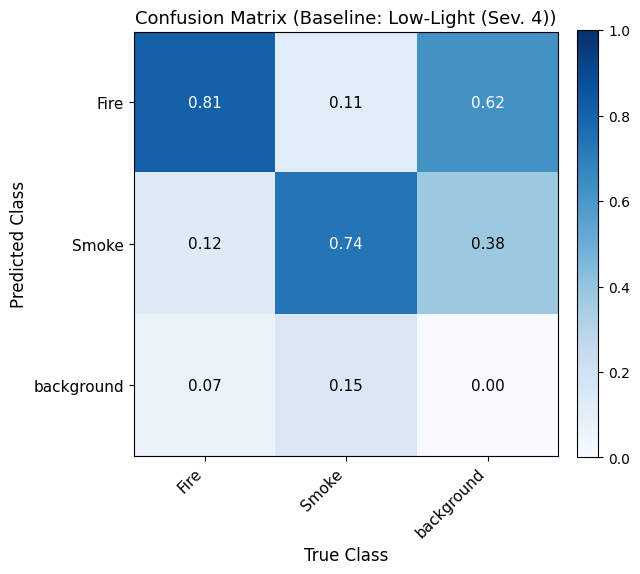

Saved: /kaggle/working/phase5_mitigation_seed123/plots/confusion_matrix_before_lowlight_sev4_normalized.png / .pdf


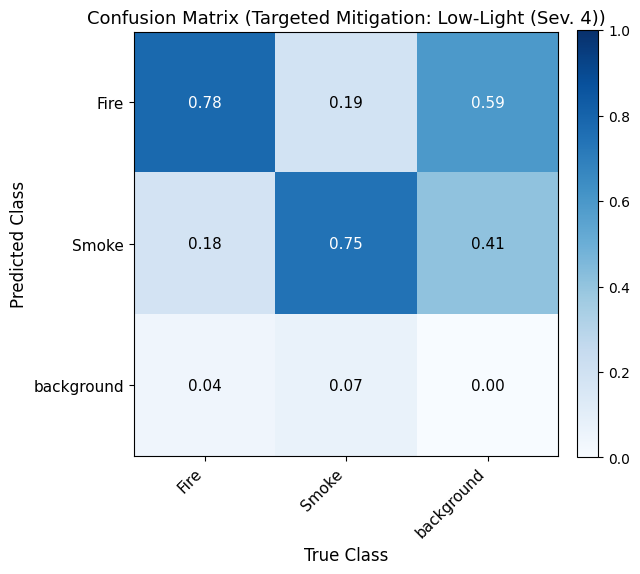

Saved: /kaggle/working/phase5_mitigation_seed123/plots/confusion_matrix_after_lowlight_sev4_normalized.png / .pdf

Gaussian Noise severity 4...
Ultralytics 8.4.137 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 634.1±42.0 MB/s, size: 352.3 KB)
val: Scanning /kaggle/input/datasets/mdshaparan/output-result-03/degraded_datasets/gaussian_noise/severity_4/labels... 1715 images, 287 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1715/1715 1.1Kit/s 1.5s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/mdshaparan/output-result-03/degraded_datasets/gaussian_noise/severity_4 is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 108/108 4.7it/s 22.9s0.2s
                   all       1715       2790      0.664      0.356      0.371      0.276
Speed: 0.8ms preprocess, 9.5ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to 

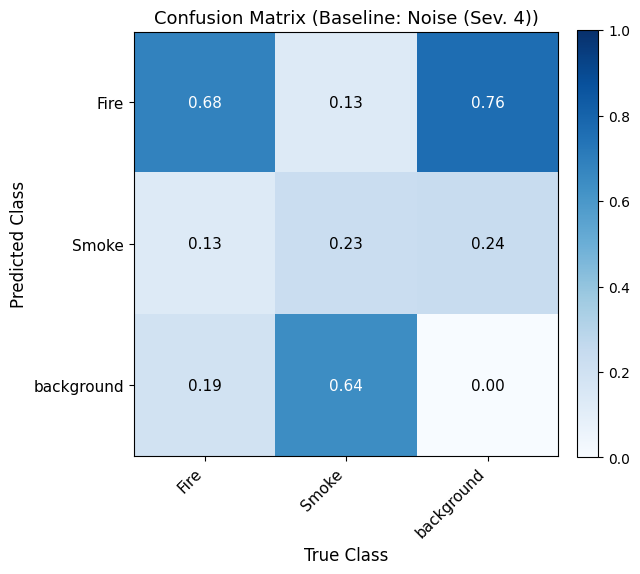

Saved: /kaggle/working/phase5_mitigation_seed123/plots/confusion_matrix_before_noise_sev4_normalized.png / .pdf


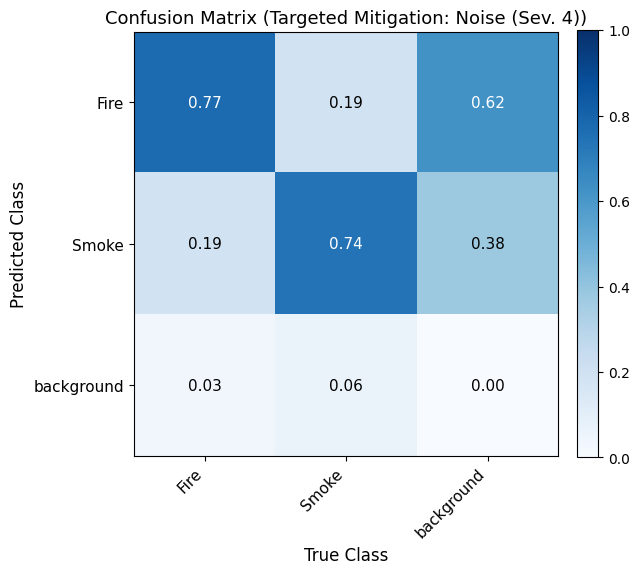

Saved: /kaggle/working/phase5_mitigation_seed123/plots/confusion_matrix_after_noise_sev4_normalized.png / .pdf


In [35]:
def compute_confusion_matrix_df(model, images_dir, name, conf=EVAL_CONF, iou=IOU_THRESHOLD, imgsz=IMG_SIZE):
    yaml_path = os.path.join(LOGS_DIR, f"data_{name}.yaml")
    make_data_yaml(images_dir, yaml_path, CLASS_NAMES)
    temp_plot_dir = os.path.join(LOGS_DIR, f"cm_temp_{name}")
    metrics = model.val(
        data=yaml_path, imgsz=imgsz, conf=conf, iou=iou, split="val",
        device=DEVICE, verbose=False, plots=True, save_json=False,
        project=temp_plot_dir, name="run", exist_ok=True,
    )
    cm = metrics.confusion_matrix.matrix
    n = cm.shape[0]
    labels = CLASS_NAMES + ["background"] if n == len(CLASS_NAMES) + 1 else [f"class_{i}" for i in range(n)]
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)
    cm_df.index.name = "Predicted"
    cm_df.columns.name = "True"
    return cm_df

def plot_normalized_confusion_matrix(cm_df, title, save_name):
    cm = cm_df.values.astype(float)
    col_sums = cm.sum(axis=0, keepdims=True)
    norm = np.divide(cm, col_sums, out=np.zeros_like(cm), where=col_sums != 0)

    fig, ax = plt.subplots(figsize=(6.5, 6))
    im = ax.imshow(norm, cmap="Blues", vmin=0, vmax=1)
    labels = list(cm_df.index)
    ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=11)
    ax.set_yticklabels(labels, fontsize=11)
    ax.set_xlabel("True Class", fontsize=12); ax.set_ylabel("Predicted Class", fontsize=12)
    ax.set_title(title, fontsize=13)
    for i in range(len(labels)):
        for j in range(len(labels)):
            val = norm[i, j]
            color = "white" if val > 0.5 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color, fontsize=11)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    for ext in ("png", "pdf"):
        plt.savefig(os.path.join(PLOTS_DIR, f"{save_name}.{ext}"), dpi=DPI, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"Saved: {os.path.join(PLOTS_DIR, save_name)}.png / .pdf")

condition_short = {
    "Clean test set": "Clean",
    "Low-Light severity 4": "Low-Light (Sev. 4)",
    "Gaussian Noise severity 4": "Noise (Sev. 4)",
}

conditions_for_cm = [
    ("Clean test set", CLEAN_TEST_IMAGES_DIR, "clean"),
    ("Low-Light severity 4", os.path.join(DEGRADATION_DIRS["Low Light"], "severity_4", "images"), "lowlight_sev4"),
    ("Gaussian Noise severity 4", os.path.join(DEGRADATION_DIRS["Gaussian Noise"], "severity_4", "images"), "noise_sev4"),
]

for label, img_dir, tag in conditions_for_cm:
    if not os.path.isdir(img_dir):
        print(f"Skipping {label}: directory not found.")
        continue
    print(f"\n{label}...")
    cm_before = compute_confusion_matrix_df(before_model, img_dir, f"cm_before_{tag}")
    cm_after = compute_confusion_matrix_df(after_model, img_dir, f"cm_after_{tag}")
    cm_before.to_csv(os.path.join(RESULTS_DIR, f"confusion_matrix_before_{tag}.csv"))
    cm_after.to_csv(os.path.join(RESULTS_DIR, f"confusion_matrix_after_{tag}.csv"))
    short = condition_short.get(label, label)
    plot_normalized_confusion_matrix(cm_before, f"Confusion Matrix ({BEFORE_LABEL}: {short})", f"confusion_matrix_before_{tag}_normalized")
    plot_normalized_confusion_matrix(cm_after, f"Confusion Matrix ({AFTER_LABEL}: {short})", f"confusion_matrix_after_{tag}_normalized")

## Cell 14 — Precision-Recall curves (Before + After)

Ultralytics 8.4.137 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 84.9±26.7 MB/s, size: 43.2 KB)
val: Scanning /kaggle/input/datasets/mdshaparan/output-result-03/clean_test_set/labels... 1715 images, 287 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1715/1715 1.2Kit/s 1.4s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/mdshaparan/output-result-03/clean_test_set is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 108/108 4.9it/s 21.9s0.2s
                   all       1715       2790      0.869      0.763      0.828      0.625
Speed: 0.8ms preprocess, 9.3ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /kaggle/working/phase5_mitigation_seed123/plots/pr_curve_pr_before_clean/run


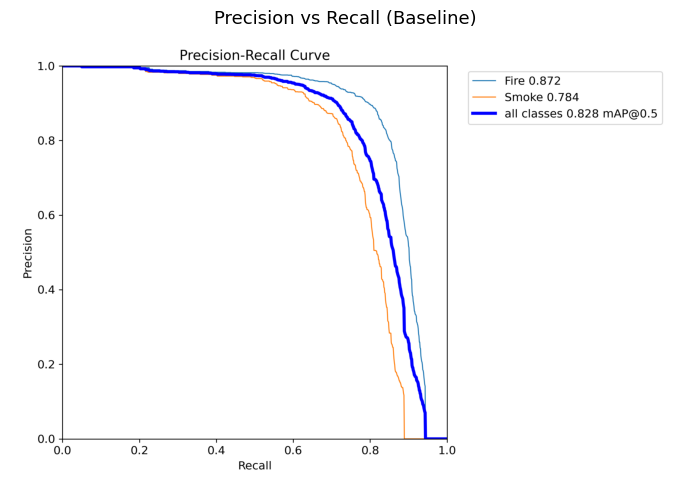

Saved: /kaggle/working/phase5_mitigation_seed123/plots/pr_curve_pr_before_clean.png / .pdf
Ultralytics 8.4.137 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 53.7±23.6 MB/s, size: 31.0 KB)
val: Scanning /kaggle/input/datasets/mdshaparan/output-result-03/clean_test_set/labels... 1715 images, 287 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1715/1715 1.3Kit/s 1.4s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/mdshaparan/output-result-03/clean_test_set is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 108/108 4.8it/s 22.6s0.2s
                   all       1715       2790      0.879      0.749      0.823      0.618
Speed: 0.8ms preprocess, 9.5ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /kaggle/working/phase5_mitigation_seed123/plots/pr_curve_pr_after_clean/run


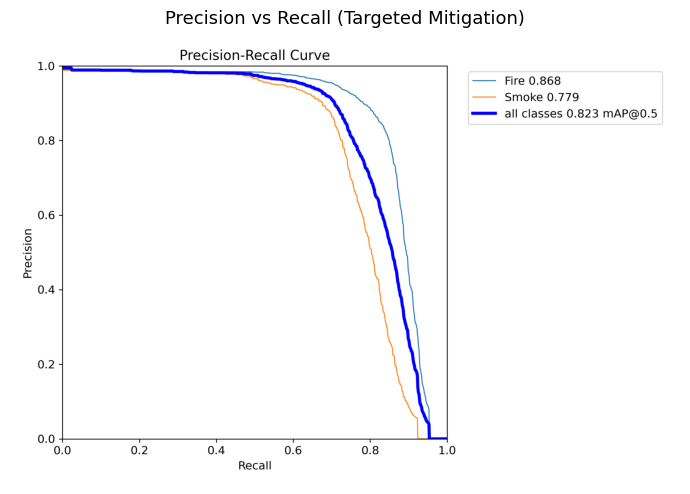

Saved: /kaggle/working/phase5_mitigation_seed123/plots/pr_curve_pr_after_clean.png / .pdf


In [36]:
def plot_pr_curve(model, images_dir, name, display_label, conf=0.001, iou=IOU_THRESHOLD, imgsz=IMG_SIZE):
    yaml_path = os.path.join(LOGS_DIR, f"data_{name}.yaml")
    make_data_yaml(images_dir, yaml_path, CLASS_NAMES)
    save_dir = os.path.join(PLOTS_DIR, f"pr_curve_{name}")
    os.makedirs(save_dir, exist_ok=True)
    model.val(
        data=yaml_path, imgsz=imgsz, conf=conf, iou=iou, split="val",
        device=DEVICE, verbose=False, plots=True, save_json=False,
        project=save_dir, name="run", exist_ok=True,
    )
    run_dir = os.path.join(save_dir, "run")
    candidates = ["BoxPR_curve.png", "PR_curve.png"]
    found = None
    for c in candidates:
        p = os.path.join(run_dir, c)
        if os.path.exists(p):
            found = p
            break
    if found is None:
        print(f"WARNING: no PR curve file found in {run_dir}")
        return

    img = plt.imread(found)
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"Precision vs Recall ({display_label})", fontsize=13, pad=10)
    plt.tight_layout()
    final_path_png = os.path.join(PLOTS_DIR, f"pr_curve_{name}.png")
    final_path_pdf = os.path.join(PLOTS_DIR, f"pr_curve_{name}.pdf")
    plt.savefig(final_path_png, dpi=DPI, bbox_inches="tight")
    plt.savefig(final_path_pdf, dpi=DPI, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"Saved: {final_path_png} / .pdf")

plot_pr_curve(before_model, CLEAN_TEST_IMAGES_DIR, "pr_before_clean", BEFORE_LABEL)
plot_pr_curve(after_model, CLEAN_TEST_IMAGES_DIR, "pr_after_clean", AFTER_LABEL)

## Cell 15 — Before vs After comparison table + improvement percentage

In [37]:
merged = before_df.merge(
    after_df, on=["Degradation", "Severity"], suffixes=("_Before", "_After")
)

for metric in ["Precision", "Recall", "mAP50", "mAP50_95"]:
    merged[f"{metric}_Improvement_Pct"] = (
        (merged[f"{metric}_After"] - merged[f"{metric}_Before"]) / merged[f"{metric}_Before"].replace(0, np.nan)
    ) * 100.0

comparison_csv = os.path.join(RESULTS_DIR, "before_after_comparison.csv")
merged.to_csv(comparison_csv, index=False)
print("Saved:", comparison_csv)
merged

Saved: /kaggle/working/phase5_mitigation_seed123/results/before_after_comparison.csv


,Model_Before,Degradation,Severity,Precision_Before,Recall_Before,mAP50_Before,mAP50_95_Before,Fire_AP50_Before,Smoke_AP50_Before,Model_After,Precision_After,Recall_After,mAP50_After,mAP50_95_After,Fire_AP50_After,Smoke_AP50_After,Precision_Improvement_Pct,Recall_Improvement_Pct,mAP50_Improvement_Pct,mAP50_95_Improvement_Pct
0,Before,Clean,0,0.869361,0.762934,0.828040,0.625484,0.872152,0.783928,After,0.879403,0.748932,0.823173,0.617947,0.867747,0.778600,1.155011,-1.835314,-0.587698,-1.204956
1,Before,Gaussian Noise,1,0.855555,0.716088,0.783998,0.590691,0.851942,0.716054,After,0.877305,0.751399,0.823863,0.618240,0.869415,0.778311,2.542197,4.931042,5.084800,4.663904
2,Before,Gaussian Noise,2,0.775929,0.576955,0.636428,0.484954,0.761404,0.511453,After,0.878098,0.743523,0.822191,0.616793,0.868549,0.775834,13.167337,28.870046,29.188325,27.185793
3,Before,Gaussian Noise,3,0.783000,0.465214,0.516404,0.402309,0.644998,0.387811,After,0.867966,0.736188,0.819601,0.612525,0.869728,0.769474,10.851360,58.247387,58.712930,52.252250
4,Before,Gaussian Noise,4,0.664069,0.356103,0.370867,0.276117,0.513996,0.227737,After,0.859327,0.734568,0.810125,0.607751,0.864742,0.755507,29.403137,106.279751,118.440945,120.106427
5,Before,Motion Blur,1,0.877249,0.756887,0.827109,0.624187,0.873843,0.780376,After,0.881971,0.743592,0.821254,0.616324,0.869296,0.773213,0.538292,-1.756631,-0.707847,-1.259810
6,Before,Motion Blur,2,0.871974,0.731861,0.809976,0.603373,0.851552,0.768400,After,0.880633,0.732136,0.809586,0.600716,0.860006,0.759166,0.993093,0.037593,-0.048168,-0.440412
7,Before,Motion Blur,3,0.870828,0.690419,0.775272,0.566320,0.818269,0.732274,After,0.848304,0.714867,0.785591,0.573897,0.836151,0.735032,-2.586417,3.540972,1.331073,1.337940
8,Before,Motion Blur,4,0.817626,0.657045,0.724563,0.514225,0.757586,0.691539,After,0.853991,0.663319,0.748154,0.533372,0.790798,0.705510,4.447579,0.954918,3.255938,3.723417
9,Before,Low Light,1,0.875656,0.758979,0.826797,0.627010,0.870845,0.782749,After,0.878640,0.746849,0.825005,0.619368,0.870147,0.779862,0.340802,-1.598266,-0.216779,-1.218803


## Cell 16 — Publication-quality before/after plots (per-condition mAP/Precision/Recall curves)

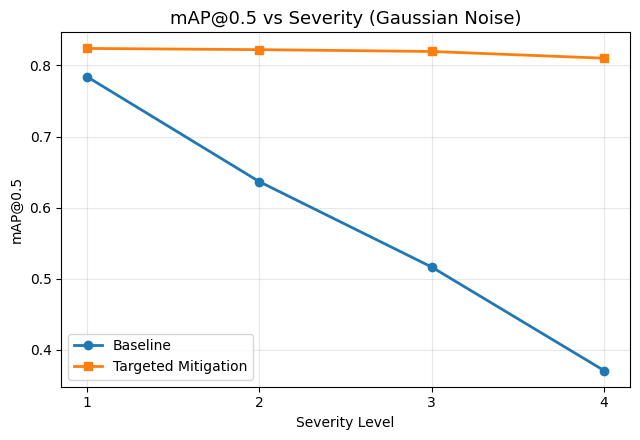

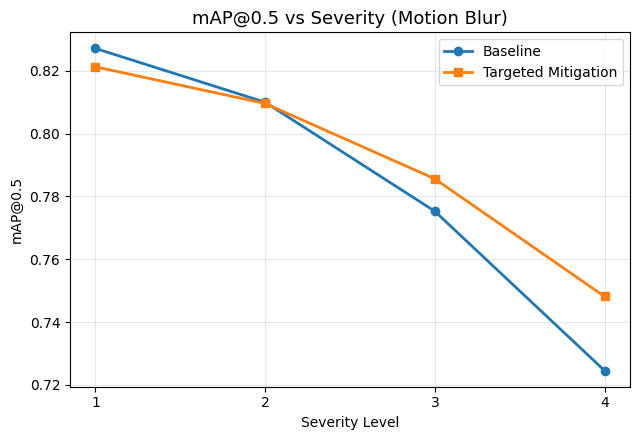

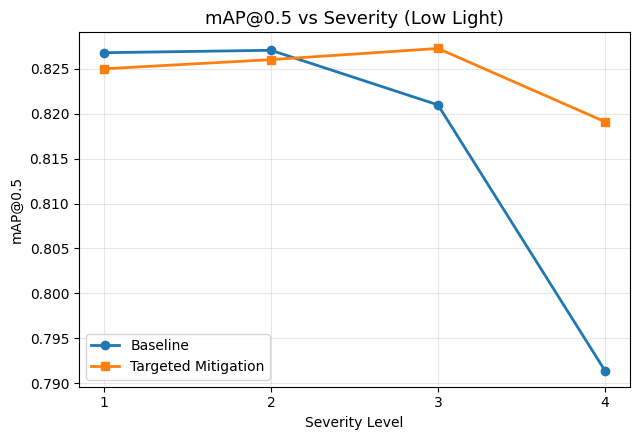

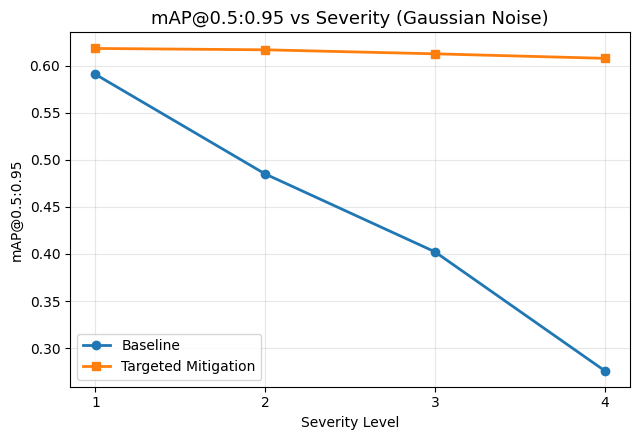

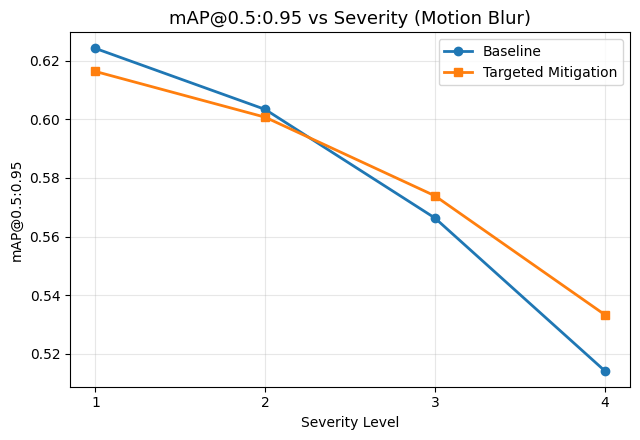

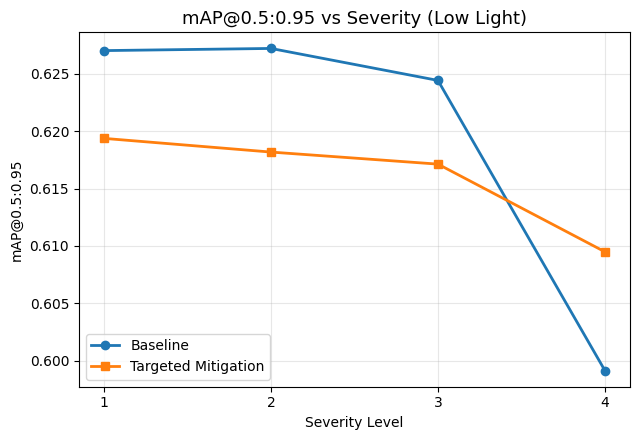

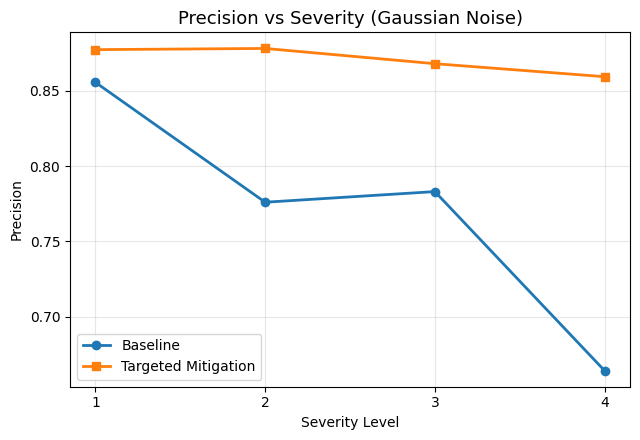

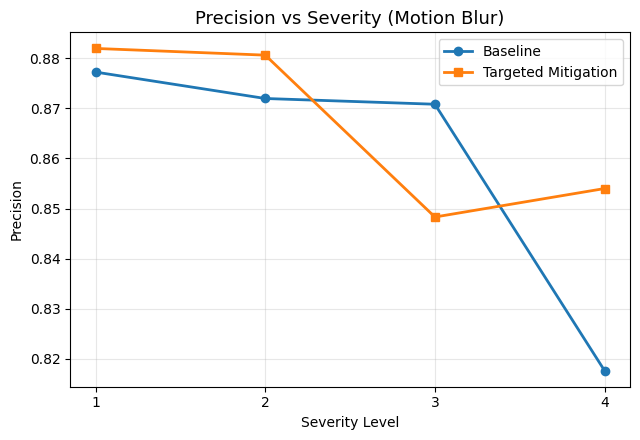

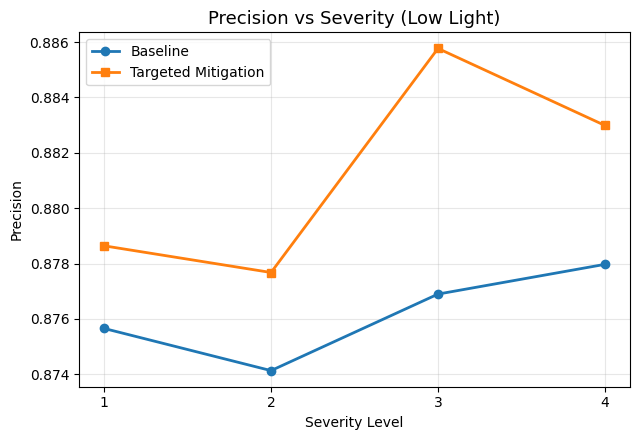

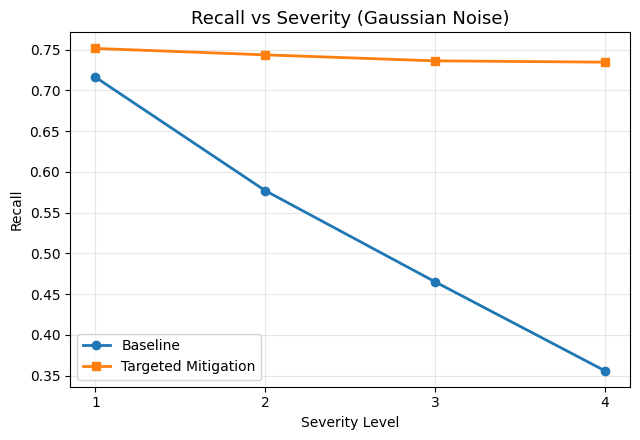

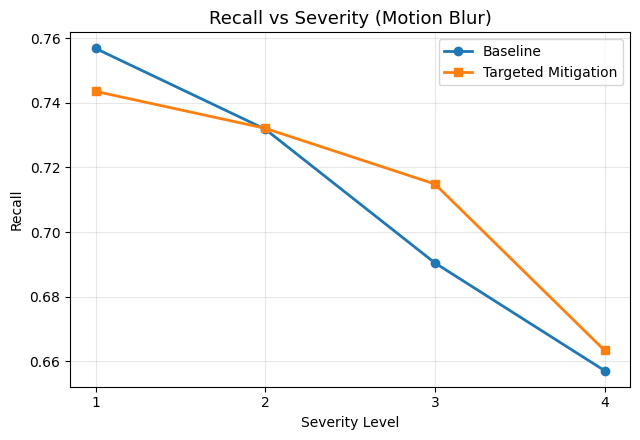

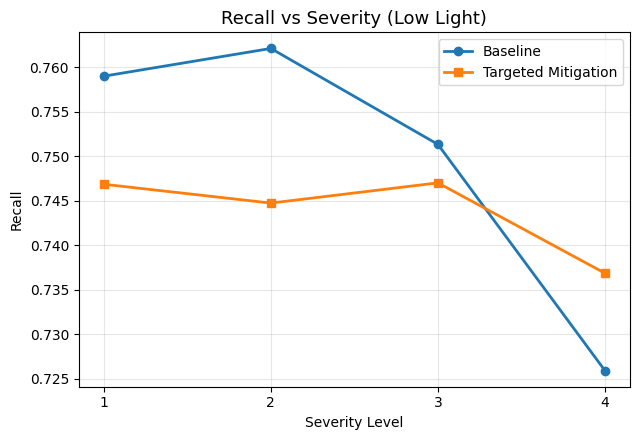

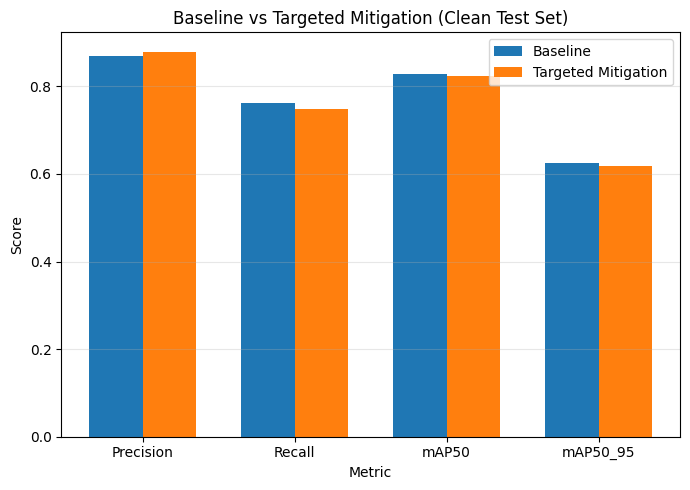

Plots saved to: /kaggle/working/phase5_mitigation_seed123/plots


In [38]:
def plot_metric_comparison(metric, filename_prefix):
    metric_display = {"mAP50": "mAP@0.5", "mAP50_95": "mAP@0.5:0.95",
                       "Precision": "Precision", "Recall": "Recall"}.get(metric, metric)
    for deg in merged["Degradation"].unique():
        if deg == "Clean":
            continue
        sub = merged[merged["Degradation"] == deg].sort_values("Severity")
        plt.figure(figsize=(6.5, 4.5))
        plt.plot(sub["Severity"], sub[f"{metric}_Before"], marker="o", linewidth=2, label=BEFORE_LABEL)
        plt.plot(sub["Severity"], sub[f"{metric}_After"], marker="s", linewidth=2, label=AFTER_LABEL)
        plt.title(f"{metric_display} vs Severity ({deg})", fontsize=13)
        plt.xlabel("Severity Level")
        plt.ylabel(metric_display)
        plt.xticks(sub["Severity"])
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        safe_deg = deg.replace(" ", "_")
        for ext in ("png", "pdf"):
            plt.savefig(os.path.join(PLOTS_DIR, f"{filename_prefix}_{safe_deg}.{ext}"), dpi=DPI, bbox_inches="tight")
        plt.show()
        plt.close()

for metric in ["mAP50", "mAP50_95", "Precision", "Recall"]:
    plot_metric_comparison(metric, f"before_after_{metric.lower()}")

clean_row = merged[merged["Degradation"] == "Clean"]
if not clean_row.empty:
    metrics_list = ["Precision", "Recall", "mAP50", "mAP50_95"]
    before_vals = [clean_row[f"{m}_Before"].values[0] for m in metrics_list]
    after_vals = [clean_row[f"{m}_After"].values[0] for m in metrics_list]
    x = np.arange(len(metrics_list))
    width = 0.35
    plt.figure(figsize=(7, 5))
    plt.bar(x - width/2, before_vals, width, label=BEFORE_LABEL)
    plt.bar(x + width/2, after_vals, width, label=AFTER_LABEL)
    plt.xticks(x, metrics_list)
    plt.xlabel("Metric")
    plt.ylabel("Score")
    plt.title(f"{BEFORE_LABEL} vs {AFTER_LABEL} (Clean Test Set)")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    for ext in ("png", "pdf"):
        plt.savefig(os.path.join(PLOTS_DIR, f"clean_before_after.{ext}"), dpi=DPI, bbox_inches="tight")
    plt.show()
    plt.close()

print("Plots saved to:", PLOTS_DIR)

## Cell 17 — Per-class AP50 plots (Fire vs Smoke, Before vs After)

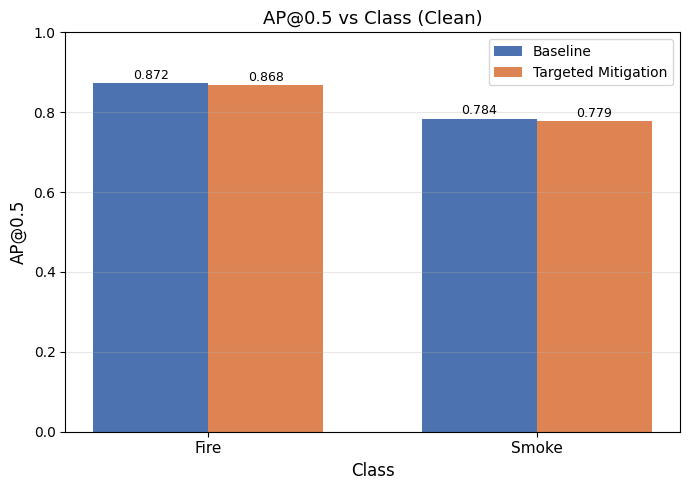

Saved: /kaggle/working/phase5_mitigation_seed123/plots/per_class_ap50_clean.png / .pdf


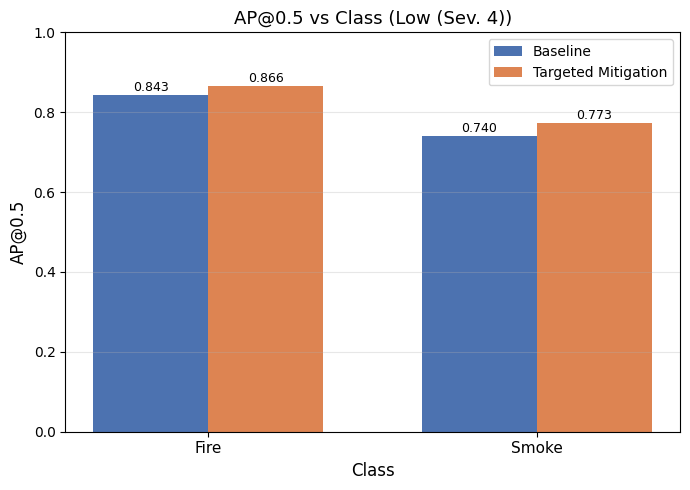

Saved: /kaggle/working/phase5_mitigation_seed123/plots/per_class_ap50_lowlight_sev4.png / .pdf


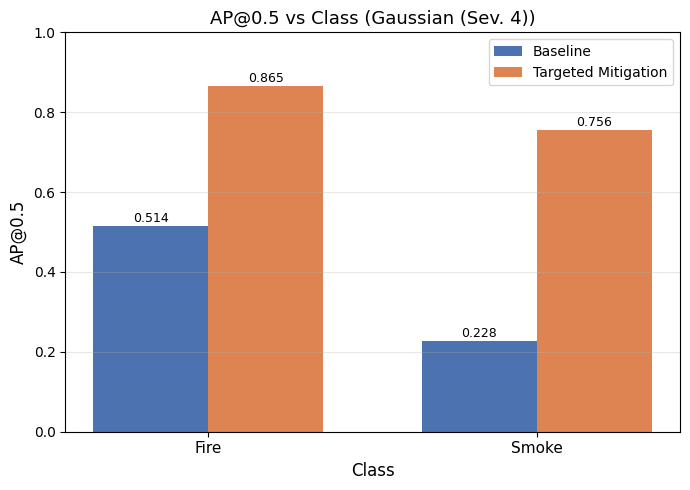

Saved: /kaggle/working/phase5_mitigation_seed123/plots/per_class_ap50_noise_sev4.png / .pdf


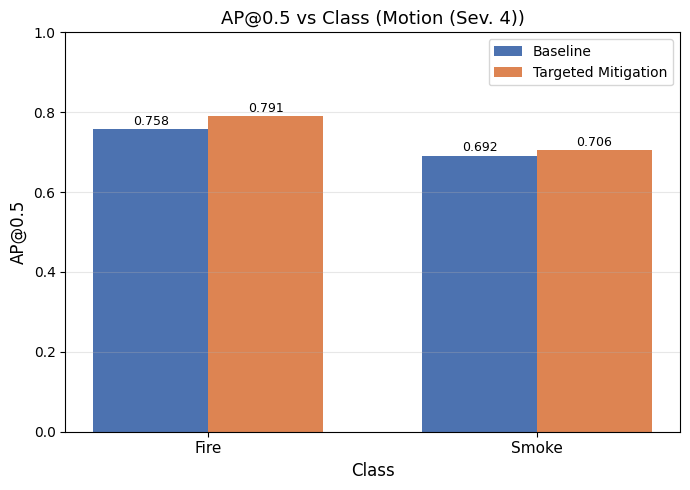

Saved: /kaggle/working/phase5_mitigation_seed123/plots/per_class_ap50_motionblur_sev4.png / .pdf


In [39]:
def plot_per_class_ap_bar(df_before, df_after, degradation, severity, save_name):
    row_before = df_before[(df_before["Degradation"] == degradation) & (df_before["Severity"] == severity)]
    row_after = df_after[(df_after["Degradation"] == degradation) & (df_after["Severity"] == severity)]
    if row_before.empty or row_after.empty:
        print(f"Skipping {save_name}: no data for {degradation} severity {severity}")
        return
    row_before = row_before.iloc[0]
    row_after = row_after.iloc[0]

    ap_cols = [f"{c}_AP50" for c in CLASS_NAMES]
    before_vals = [row_before.get(c) for c in ap_cols]
    after_vals = [row_after.get(c) for c in ap_cols]

    x = np.arange(len(CLASS_NAMES))
    width = 0.35
    fig, ax = plt.subplots(figsize=(7, 5))
    bars1 = ax.bar(x - width/2, before_vals, width, label=BEFORE_LABEL, color="#4C72B0")
    bars2 = ax.bar(x + width/2, after_vals, width, label=AFTER_LABEL, color="#DD8452")
    for bars in (bars1, bars2):
        for b in bars:
            h = b.get_height()
            if h is not None:
                ax.annotate(f"{h:.3f}", xy=(b.get_x() + b.get_width() / 2, h),
                            xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, fontsize=11)
    ax.set_xlabel("Class", fontsize=12)
    ax.set_ylabel("AP@0.5", fontsize=12)
    ax.set_ylim(0, 1.0)
    short_cond = "Clean" if degradation == "Clean" else f"{degradation.split()[0]} (Sev. {severity})"
    ax.set_title(f"AP@0.5 vs Class ({short_cond})", fontsize=13)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    for ext in ("png", "pdf"):
        plt.savefig(os.path.join(PLOTS_DIR, f"{save_name}.{ext}"), dpi=DPI, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"Saved: {os.path.join(PLOTS_DIR, save_name)}.png / .pdf")

plot_per_class_ap_bar(before_df, after_df, "Clean", 0, "per_class_ap50_clean")
plot_per_class_ap_bar(before_df, after_df, "Low Light", 4, "per_class_ap50_lowlight_sev4")
plot_per_class_ap_bar(before_df, after_df, "Gaussian Noise", 4, "per_class_ap50_noise_sev4")
plot_per_class_ap_bar(before_df, after_df, "Motion Blur", 4, "per_class_ap50_motionblur_sev4")

## Cell 18 — Sample prediction visualizations (paired original | predicted, 2x4 grids)

Saved: /kaggle/working/phase5_mitigation_seed123/plots/sample_predictions_clean_before.png / .pdf


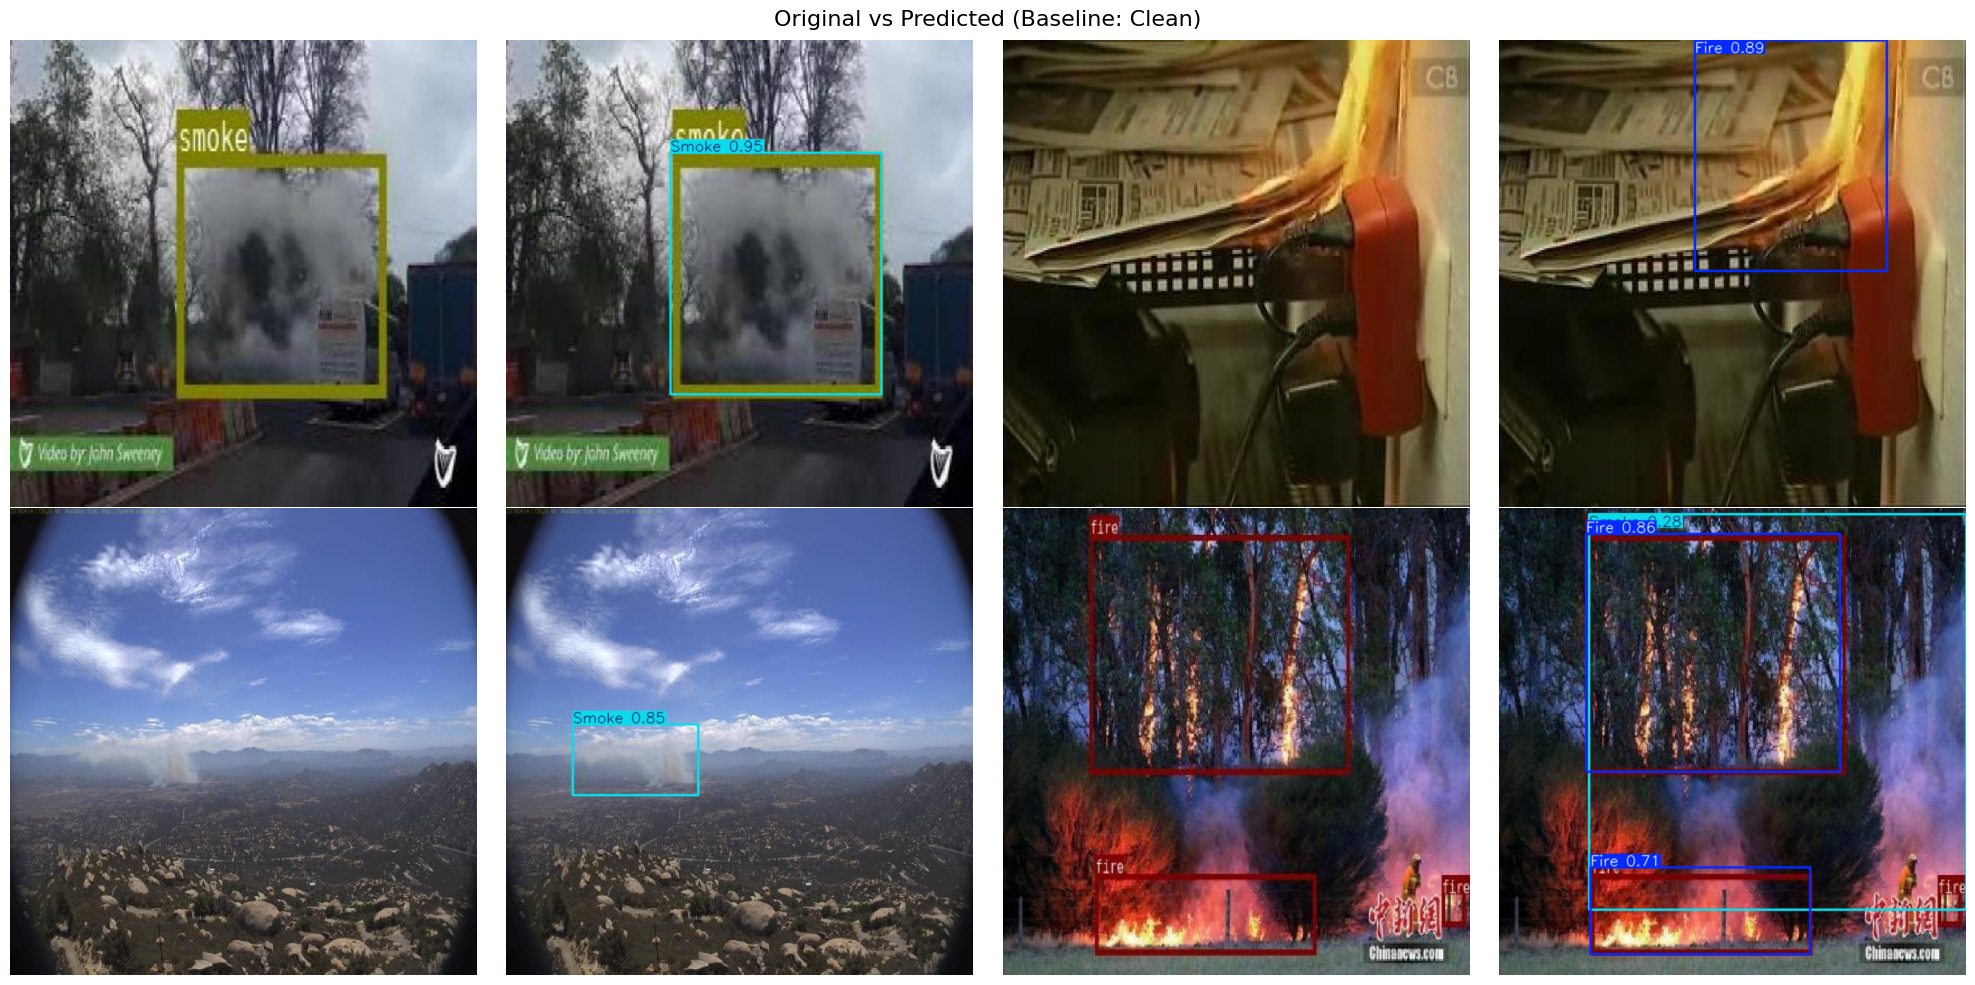

Saved: /kaggle/working/phase5_mitigation_seed123/plots/sample_predictions_lowlight4_before.png / .pdf


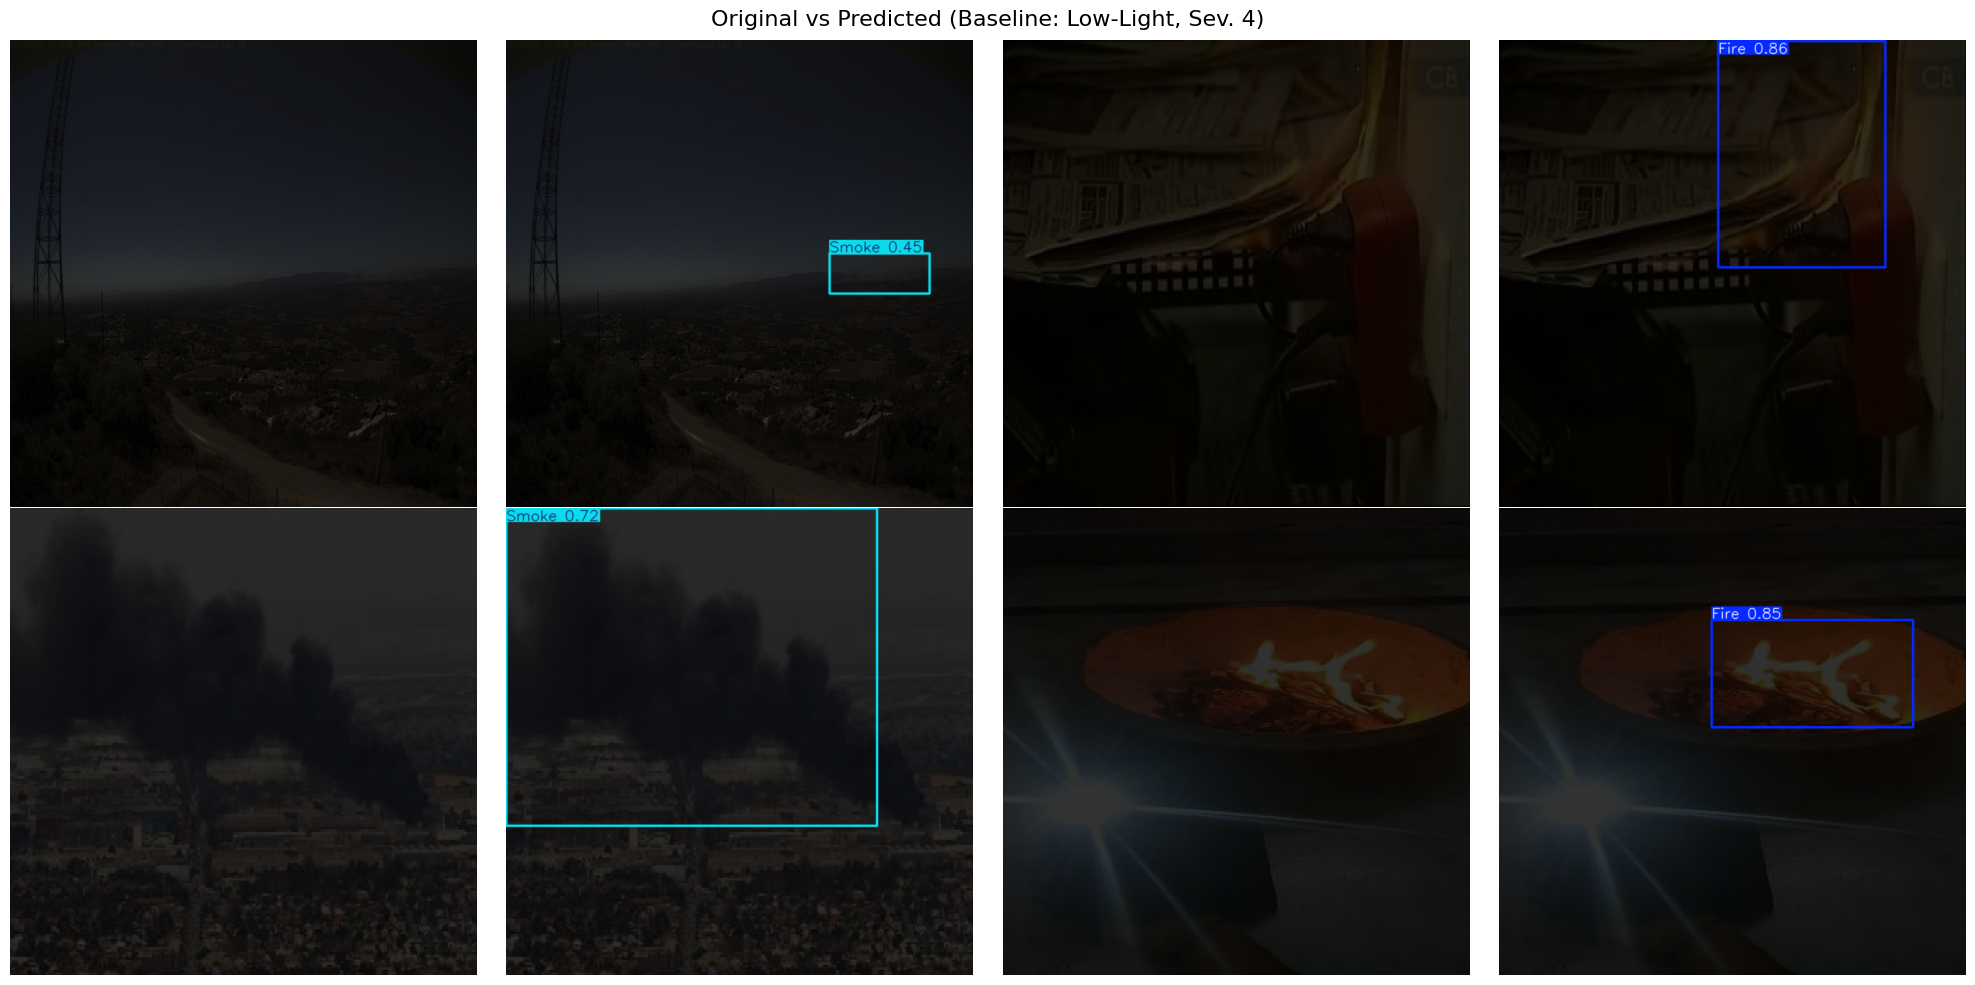

Saved: /kaggle/working/phase5_mitigation_seed123/plots/sample_predictions_noise4_before.png / .pdf


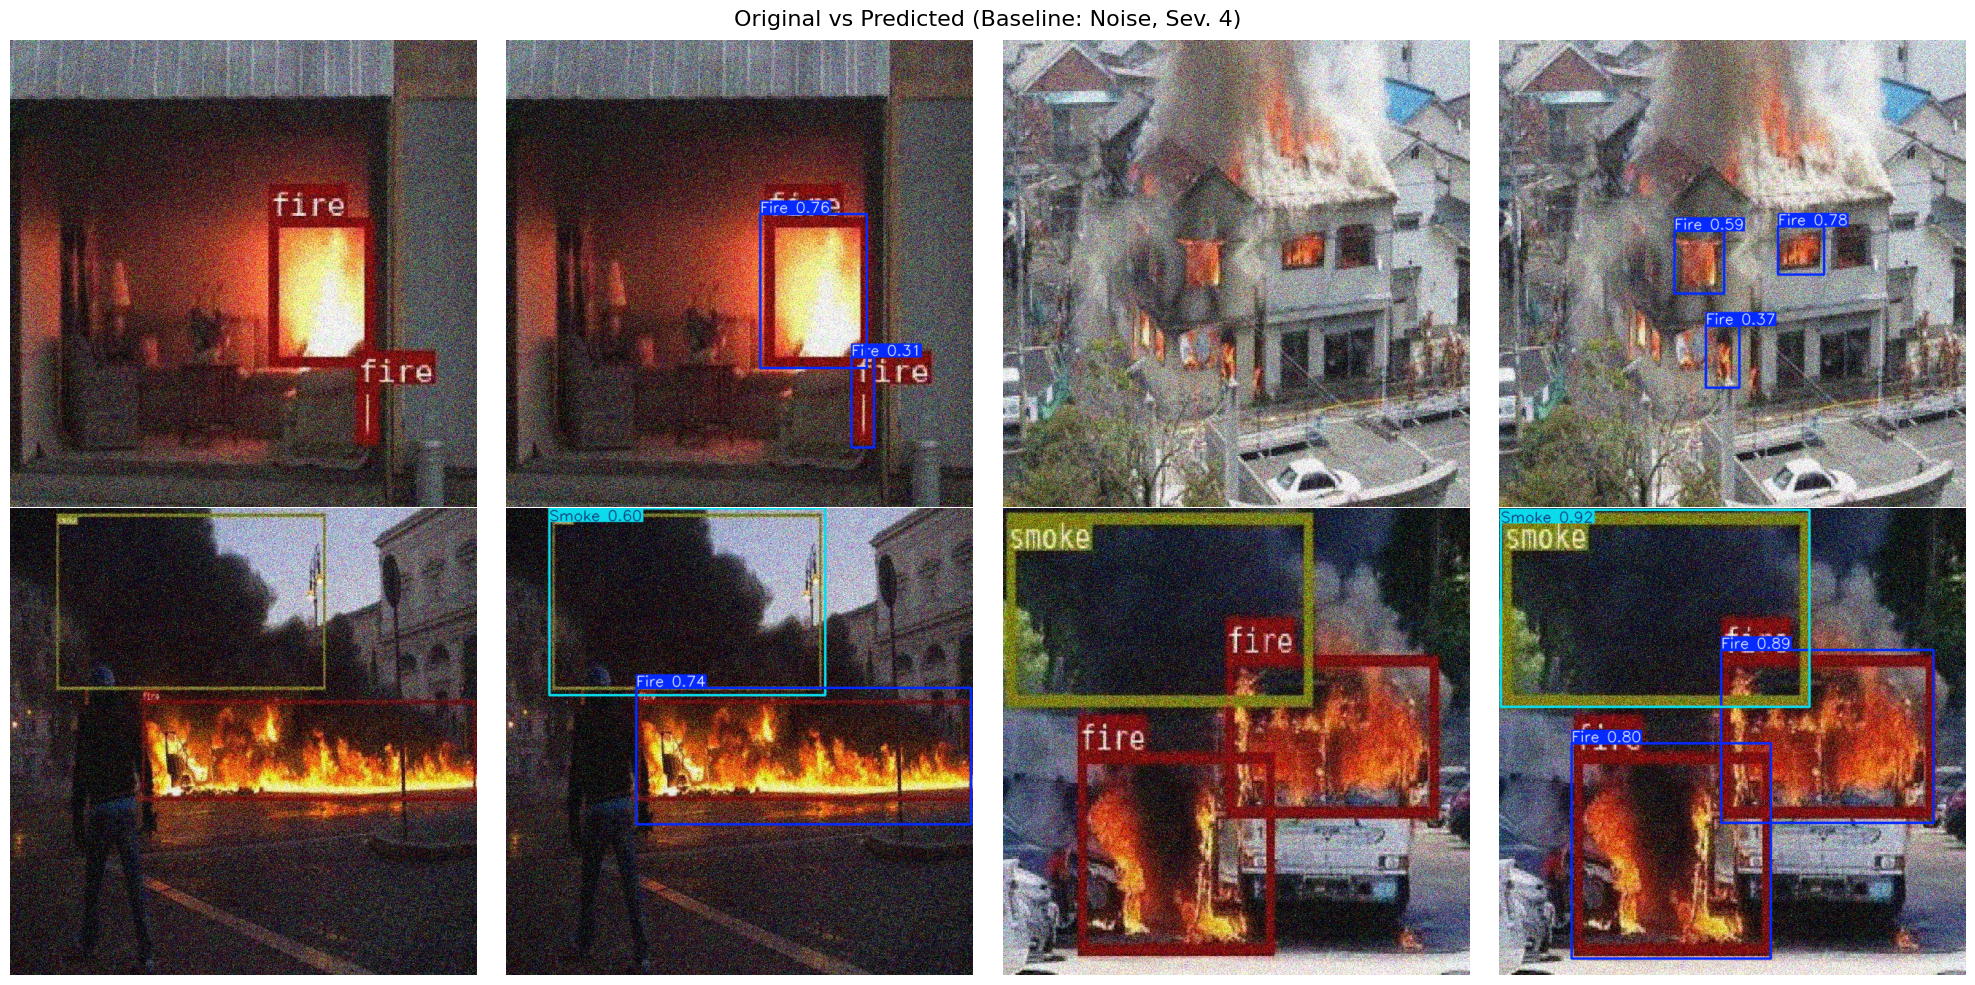

In [42]:
def show_paired_predictions(model, images_dir, n_samples=4, imgsz=IMG_SIZE, conf=CONF_THRESHOLD,
                             title="", save_name=None):
    image_paths = glob.glob(os.path.join(images_dir, "*"))
    if len(image_paths) == 0:
        print(f"No images found in {images_dir}")
        return
    selected = random.sample(image_paths, min(n_samples, len(image_paths)))
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    for idx, img_path in enumerate(selected):
        row = idx // 2
        col_pair = (idx % 2) * 2
        orig_rgb = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        result = model.predict(img_path, imgsz=imgsz, conf=conf, device=DEVICE, verbose=False)[0]
        annotated_rgb = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
        axes[row, col_pair].imshow(orig_rgb); axes[row, col_pair].axis("off")
        axes[row, col_pair + 1].imshow(annotated_rgb); axes[row, col_pair + 1].axis("off")
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    if save_name:
        for ext in ("png", "pdf"):
            plt.savefig(os.path.join(PLOTS_DIR, f"{save_name}.{ext}"), dpi=DPI, bbox_inches="tight")
        print(f"Saved: {os.path.join(PLOTS_DIR, save_name)}.png / .pdf")
    plt.show()
    plt.close()

lowlight_sev4_dir = os.path.join(DEGRADATION_DIRS["Low Light"], "severity_4", "images")
noise_sev4_dir = os.path.join(DEGRADATION_DIRS["Gaussian Noise"], "severity_4", "images")

show_paired_predictions(after_model, CLEAN_TEST_IMAGES_DIR, n_samples=4,
                         title=f"Original vs Predicted ({AFTER_LABEL}: Clean)",
                         save_name="sample_predictions_clean_after")

show_paired_predictions(after_model, lowlight_sev4_dir, n_samples=4,
                         title=f"Original vs Predicted ({AFTER_LABEL}: Low-Light, Sev. 4)",
                         save_name="sample_predictions_lowlight4_after")

show_paired_predictions(after_model, noise_sev4_dir, n_samples=4,
                         title=f"Original vs Predicted ({AFTER_LABEL}: Noise, Sev. 4)",
                         save_name="sample_predictions_noise4_after")

show_paired_predictions(before_model, CLEAN_TEST_IMAGES_DIR, n_samples=4,
                         title=f"Original vs Predicted ({BEFORE_LABEL}: Clean)",
                         save_name="sample_predictions_clean_before")

show_paired_predictions(before_model, lowlight_sev4_dir, n_samples=4,
                         title=f"Original vs Predicted ({BEFORE_LABEL}: Low-Light, Sev. 4)",
                         save_name="sample_predictions_lowlight4_before")

show_paired_predictions(before_model, noise_sev4_dir, n_samples=4,
                         title=f"Original vs Predicted ({BEFORE_LABEL}: Noise, Sev. 4)",
                         save_name="sample_predictions_noise4_before")

Searching for VISIBLE Before-model failure cases (Low-Light severity 4)...
Found 0 visible failure case(s).
Not enough visible failures at severity 4 -- trying severity 3 as fallback...
Total after fallback: 4


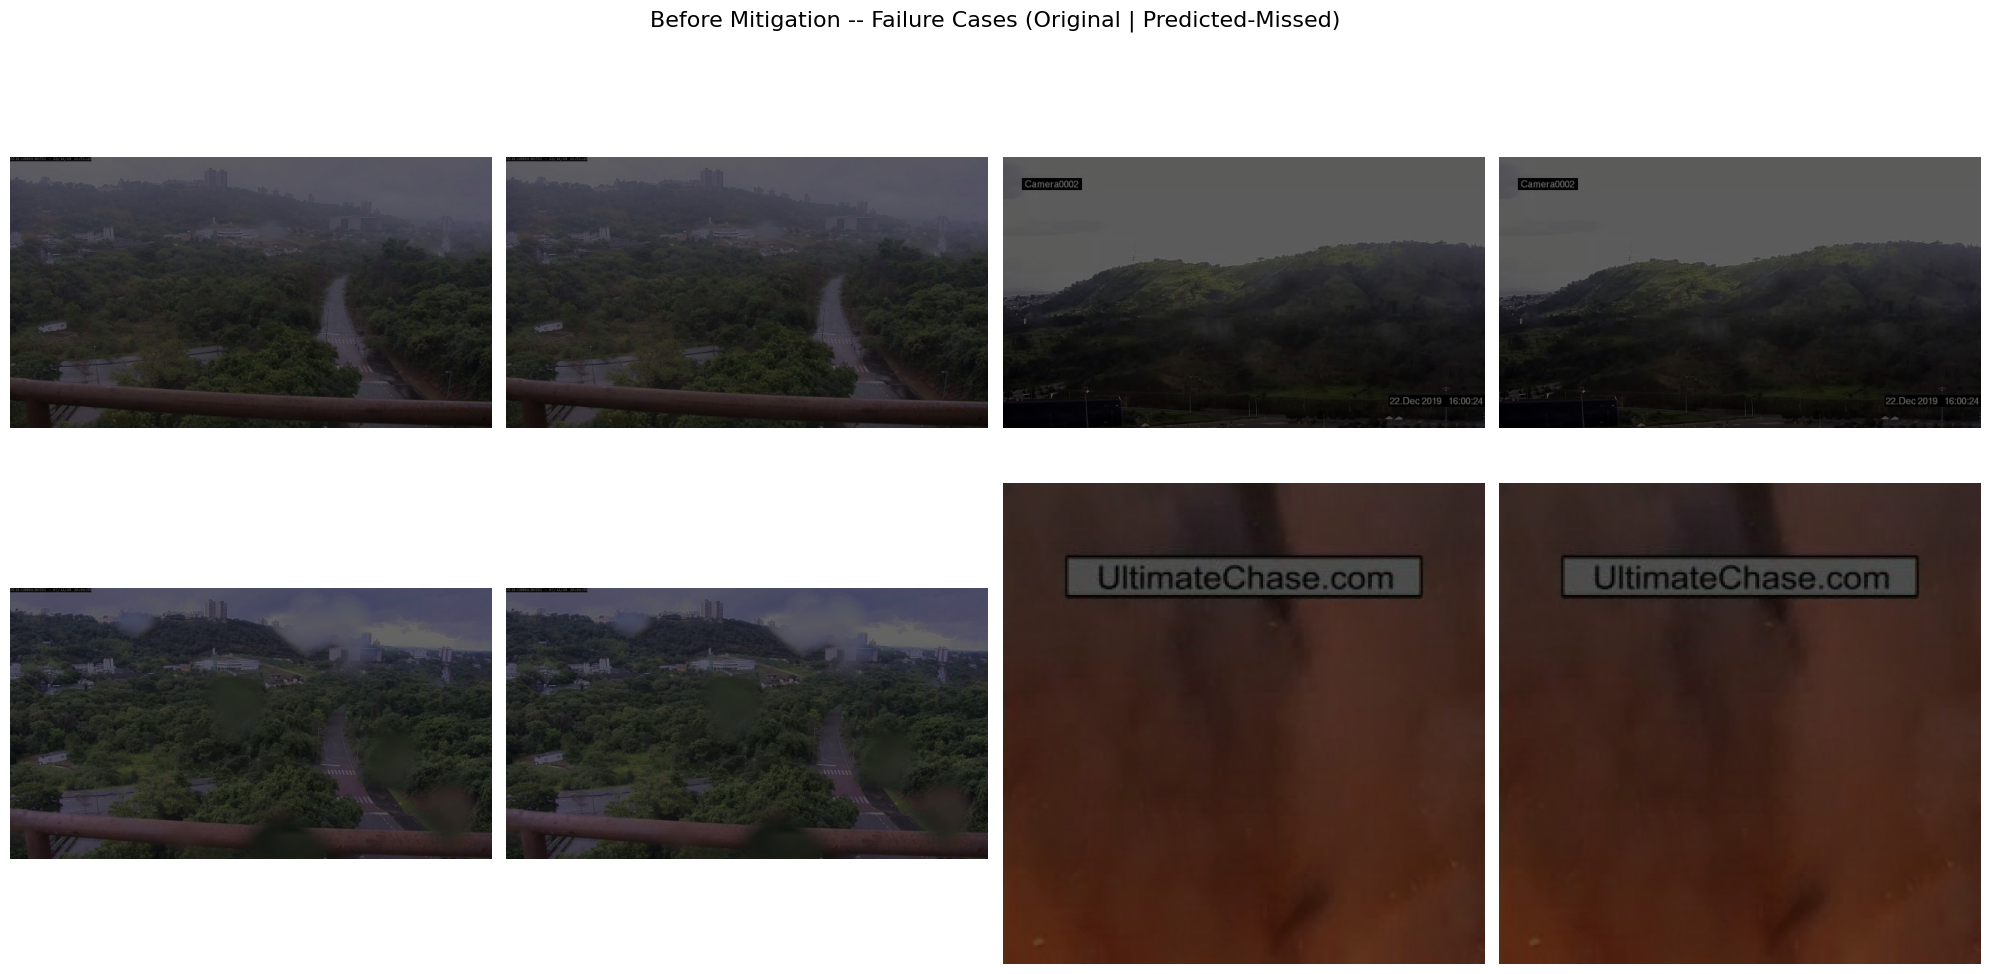

Saved: sample_predictions_before_failures.png / .pdf


In [43]:
import random
import time

def find_before_failure_images_visible(model, images_dir, n_needed=4, imgsz=IMG_SIZE, conf=CONF_THRESHOLD,
                                         max_scan=300, min_brightness=40):
    image_paths = sorted(glob.glob(os.path.join(images_dir, "*")))[:max_scan]

  
    local_rng = random.Random(time.time())
    local_rng.shuffle(image_paths)

    failures = []
    for img_path in image_paths:
        result = model.predict(img_path, imgsz=imgsz, conf=conf, device=DEVICE, verbose=False)[0]
        if len(result.boxes) == 0:
            img = cv2.imread(img_path)
            mean_brightness = img.mean()
            if mean_brightness >= min_brightness:
                failures.append(img_path)
        if len(failures) >= n_needed:
            break
    return failures

print("Searching for VISIBLE Before-model failure cases (Low-Light severity 4)...")
before_failures = find_before_failure_images_visible(before_model, lowlight_sev4_dir, n_needed=4, min_brightness=40)
print(f"Found {len(before_failures)} visible failure case(s).")

if len(before_failures) < 4:
    print("Not enough visible failures at severity 4 -- trying severity 3 as fallback...")
    lowlight_sev3_dir = os.path.join(DEGRADATION_DIRS["Low Light"], "severity_3", "images")
    extra = find_before_failure_images_visible(before_model, lowlight_sev3_dir,
                                                n_needed=4 - len(before_failures), min_brightness=40)
    before_failures.extend(extra)
    print(f"Total after fallback: {len(before_failures)}")

if before_failures:
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    for idx, img_path in enumerate(before_failures):
        row = idx // 2
        col_pair = (idx % 2) * 2
        orig_rgb = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        result = before_model.predict(img_path, imgsz=IMG_SIZE, conf=CONF_THRESHOLD, device=DEVICE, verbose=False)[0]
        annotated_rgb = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
        axes[row, col_pair].imshow(orig_rgb); axes[row, col_pair].axis("off")
        axes[row, col_pair + 1].imshow(annotated_rgb); axes[row, col_pair + 1].axis("off")
    plt.suptitle("Before Mitigation -- Failure Cases (Original | Predicted-Missed)", fontsize=16)
    plt.tight_layout()
    for ext in ("png", "pdf"):
        plt.savefig(os.path.join(PLOTS_DIR, f"sample_predictions_before_failures.{ext}"), dpi=DPI)
    plt.show()
    plt.close()
    print("Saved: sample_predictions_before_failures.png / .pdf")
else:
    print("No visible failure cases found -- try lowering min_brightness or increasing max_scan.")

## Cell 19 — Inference speed / latency / FPS / model size (Before vs After)

In [44]:
def measure_inference_speed(model, images_dir, n_samples=100, imgsz=IMG_SIZE, warmup=10):
    image_paths = sorted(glob.glob(os.path.join(images_dir, "*")))[:n_samples]
    if len(image_paths) == 0:
        return None
    for p in image_paths[:warmup]:
        _ = model.predict(p, imgsz=imgsz, device=DEVICE, verbose=False)
    times = []
    for p in image_paths:
        start = time.perf_counter()
        _ = model.predict(p, imgsz=imgsz, device=DEVICE, verbose=False)
        times.append((time.perf_counter() - start) * 1000)
    times = np.array(times)
    return {
        "Mean_Inference_ms": float(times.mean()),
        "Std_Inference_ms": float(times.std()),
        "FPS": float(1000.0 / times.mean()),
        "N_Samples": len(times),
    }

def get_model_size_mb(path):
    return os.path.getsize(path) / (1024 * 1024)

def get_param_count_m(model):
    return sum(p.numel() for p in model.model.parameters()) / 1e6

print("Measuring inference speed...")
speed_before = measure_inference_speed(before_model, CLEAN_TEST_IMAGES_DIR)
print("Before:", speed_before)
speed_after = measure_inference_speed(after_model, CLEAN_TEST_IMAGES_DIR)
print("After :", speed_after)

size_before = get_model_size_mb(BEFORE_MODEL_PATH)
size_after = get_model_size_mb(bundled_after_path)
params_before = get_param_count_m(before_model)
params_after = get_param_count_m(after_model)

speed_size_df = pd.DataFrame([
    {"Model": "Before (Baseline)", **speed_before, "Model_Size_MB": size_before, "Params_M": params_before},
    {"Model": "After (Mitigated)", **speed_after, "Model_Size_MB": size_after, "Params_M": params_after},
])
speed_size_csv = os.path.join(RESULTS_DIR, "inference_speed_size_comparison.csv")
speed_size_df.to_csv(speed_size_csv, index=False)
print("\nSaved:", speed_size_csv)
speed_size_df

Measuring inference speed...
Before: {'Mean_Inference_ms': 13.859023160021025, 'Std_Inference_ms': 0.8057619540720729, 'FPS': 72.15515757883206, 'N_Samples': 100}
After : {'Mean_Inference_ms': 12.80479893995107, 'Std_Inference_ms': 0.412817353552631, 'FPS': 78.09572057238574, 'N_Samples': 100}

Saved: /kaggle/working/phase5_mitigation_seed123/results/inference_speed_size_comparison.csv


,Model,Mean_Inference_ms,Std_Inference_ms,FPS,N_Samples,Model_Size_MB,Params_M
0,Before (Baseline),13.859023,0.805762,72.155158,100,18.293299,9.413574
1,After (Mitigated),12.804799,0.412817,78.095721,100,18.286829,9.413574


## Cell 20 — Save configs / logs

In [45]:
config = {
    "variant": "Variant 1 -- full-severity-range augmentation",
    "seed": SEED,
    "before_model_path": BEFORE_MODEL_PATH,
    "after_model_path": bundled_after_path,
    "train_data_yaml": DATA_YAML_PATH,
    "img_size": IMG_SIZE,
    "eval_conf": EVAL_CONF,
    "iou_threshold": IOU_THRESHOLD,
    "training_hyperparameters": {
        "epochs": TRAIN_EPOCHS, "patience": TRAIN_PATIENCE, "batch": TRAIN_BATCH,
        "optimizer": TRAIN_OPTIMIZER, "lr0": TRAIN_LR0, "lrf": TRAIN_LRF,
        "momentum": TRAIN_MOMENTUM, "weight_decay": TRAIN_WEIGHT_DECAY,
        "warmup_epochs": TRAIN_WARMUP_EPOCHS, "seed": TRAIN_SEED,
        "deterministic": TRAIN_DETERMINISTIC, "close_mosaic": TRAIN_CLOSE_MOSAIC,
    },
    "baseline_augmentation_unchanged": BASELINE_AUG,
    "targeted_augmentation_added": {
        "lowlight_prob": TARGETED_LOWLIGHT_PROB,
        "lowlight_factor_range": TARGETED_LOWLIGHT_FACTOR_RANGE,
        "noise_prob": TARGETED_NOISE_PROB,
        "noise_std_range": TARGETED_NOISE_STD_RANGE,
    },
    "diagnosis_rationale_file": rationale_path,
    "class_names": CLASS_NAMES,
    "severities_evaluated": SEVERITIES,
}
config_path = os.path.join(CONFIGS_DIR, "phase5_config.json")
with open(config_path, "w") as f:
    json.dump(config, f, indent=2)
print("Saved:", config_path)

Saved: /kaggle/working/phase5_mitigation_seed123/configs/phase5_config.json


## Cell 21 — Final verification + ZIP

In [46]:
print("=== Final Verification ===")
for f in [before_csv, after_csv, comparison_csv, config_path, bundled_after_path]:
    print(f, "exists:", os.path.exists(f))

zip_path = shutil.make_archive(f"/kaggle/working/phase5_mitigation_results_v1_seed{SEED}", "zip", OUTPUT_ROOT)
print("\nFINAL ZIP:")
print(" ", zip_path)

=== Final Verification ===
/kaggle/working/phase5_mitigation_seed123/results/before_results.csv exists: True
/kaggle/working/phase5_mitigation_seed123/results/after_results.csv exists: True
/kaggle/working/phase5_mitigation_seed123/results/before_after_comparison.csv exists: True
/kaggle/working/phase5_mitigation_seed123/configs/phase5_config.json exists: True
/kaggle/working/phase5_mitigation_seed123/models/after_mitigation_best.pt exists: True

FINAL ZIP:
  /kaggle/working/phase5_mitigation_results_v1_seed123.zip


## Cell 22 — Final summary

In [47]:
print("=" * 60)
print(f"PHASE 5 SUMMARY (VARIANT 1) -- SEED = {SEED}")
print("=" * 60)
print("Targeted failure modes addressed: Low-Light FN, Gaussian Noise FP")
print("Excluded (no supporting CAM evidence): Glare Fire FP, Fog/Cloud Smoke FP, Motion Blur")
print()
print("Before vs After comparison:")
print(merged[["Degradation", "Severity", "mAP50_Before", "mAP50_After", "mAP50_Improvement_Pct"]].to_string(index=False))
print()
best_gain = merged.loc[merged["mAP50_Improvement_Pct"].idxmax()]
print(f"Largest mAP50 improvement: {best_gain['Degradation']} severity {best_gain['Severity']} "
      f"({best_gain['mAP50_Improvement_Pct']:.2f}%)")
worst_change = merged.loc[merged["mAP50_Improvement_Pct"].idxmin()]
print(f"Smallest/most negative mAP50 change: {worst_change['Degradation']} severity {worst_change['Severity']} "
      f"({worst_change['mAP50_Improvement_Pct']:.2f}%)")
print()
print("KNOWN LIMITATION: no blanket-augmentation control run was included.")
print()
print("Output root:", OUTPUT_ROOT)
print("Final ZIP  :", zip_path)

PHASE 5 SUMMARY (VARIANT 1) -- SEED = 123
Targeted failure modes addressed: Low-Light FN, Gaussian Noise FP
Excluded (no supporting CAM evidence): Glare Fire FP, Fog/Cloud Smoke FP, Motion Blur

Before vs After comparison:
   Degradation  Severity  mAP50_Before  mAP50_After  mAP50_Improvement_Pct
         Clean         0      0.828040     0.823173              -0.587698
Gaussian Noise         1      0.783998     0.823863               5.084800
Gaussian Noise         2      0.636428     0.822191              29.188325
Gaussian Noise         3      0.516404     0.819601              58.712930
Gaussian Noise         4      0.370867     0.810125             118.440945
   Motion Blur         1      0.827109     0.821254              -0.707847
   Motion Blur         2      0.809976     0.809586              -0.048168
   Motion Blur         3      0.775272     0.785591               1.331073
   Motion Blur         4      0.724563     0.748154               3.255938
     Low Light         1   